# 3.2 Demand Prediction

In this notebook we implement Neural Networks (NNs) to predict taxi trip demand in chicago. Additionally, we compare the performances of the NNs across different complexity levels.

For NNs there are 2 "main" complexity interpretations:
- depth: number of hidden layers
- width: number of nodes per layer
So we decide to test 3 different NN structures:

__baseline model__:
- hidden layers: 2
- nodes per layer: 64

__wider model__:
- hidden layers: 2
- nodes per layer: 256

__deeper model__:
- hidden layers: 8
- nodes per layer: 64

For better comparison, we will test all three architectures with the same shared configurations.

Before training any NN, we establish simple **benchmarks** to contextualise the results.

### Data Requirements

`data/aggregated/community_area/demand_ca_6h.parquet` — from `01_07_Data_Aggregation`

## Table of Contents

- [3.2.1 Data Information](#321-data-information)
- [3.2.2 Model Configurations](#322-model-configurations)
- [3.2.3 Model Definition](#323-model-definition)
- [3.2.4 Hyperparameter Search Definition (GridSearch using Optuna)](#324-hyperparameter-search-definition-gridsearch-using-optuna)
- [Evaluation & Save Utilities](#evaluation--save-utilities)
- [3.2.5 Visualization: Model Architecture](#325-visualization-model-architecture)
- [3.2.6 Train / Val / Test Split](#326-train--val--test-split)
- [3.2.7 Feature Preparation](#327-feature-preparation)
    - [Community Area Encoding](#community-area-encoding)
- [Feature Selection](#feature-selection)
- [3.2.8 Benchmark Models](#328-benchmark-models)
- [Embed Dimension Search](#embed-dimension-search)
- [3.2.9 Baseline Model — Training](#329-baseline-model--training)
  - [3.2.9 Baseline Model — Evaluation](#329-baseline-model--evaluation)
- [3.2.10 Hyperparameter Search — Baseline Model](#3210-hyperparameter-search--baseline-model)
  - [3.2.10 Tuned Baseline — Training](#3210-tuned-baseline--training)
  - [3.2.10 Tuned Baseline — Evaluation](#3210-tuned-baseline--evaluation)
- [3.2.11 Deeper Model — Training](#3211-deeper-model--training)
  - [3.2.11 Deeper Model — Evaluation](#3211-deeper-model--evaluation)
- [3.2.12 Hyperparameter Search — Deeper Model](#3212-hyperparameter-search--deeper-model)
  - [3.2.12 Tuned Deeper — Training](#3212-tuned-deeper--training)
  - [3.2.12 Tuned Deeper — Evaluation](#3212-tuned-deeper--evaluation)
- [3.2.13 Wider Model — Training](#3213-wider-model--training)
  - [3.2.13 Wider Model — Evaluation](#3213-wider-model--evaluation)
- [3.2.14 Hyperparameter Search — Wider Model](#3214-hyperparameter-search--wider-model)
  - [3.2.14 Tuned Wider — Training](#3214-tuned-wider--training)
  - [3.2.14 Tuned Wider — Evaluation](#3214-tuned-wider--evaluation)
- [3.2.15 Visualization: Trip Count Distribution](#3215-visualization-trip-count-distribution)
- [3.2.16 Visualization: Architecture Comparison](#3216-visualization-architecture-comparison)
  - [Learning Curves](#learning-curves)
  - [Statistical Significance — Wilcoxon Signed-Rank](#statistical-significance--wilcoxon-signed-rank)


In [71]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Import packages                         #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import pandas as pd
# import matplotlib.pyplot as plt

# modeling
import copy
import random
import types
import numpy as np
import optuna
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score as _r2

# evaluation
import datetime

# model visualization
from torchinfo import summary

# reset working dir
import os
from pathlib import Path


In [72]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Reset working directory                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import __main__
_nb = getattr(__main__, "__vsc_ipynb_file__", None) or os.environ.get("JPY_SESSION_NAME")
_start = Path(_nb).resolve().parent if _nb else Path.cwd()
os.chdir(next(p for p in [_start, *_start.parents] if (p / "pyproject.toml").exists()))
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/anthony/Documents/Dokumente – MacBook Pro von Anthony/UNI/AAA/AAA_TA_2026


In [73]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Load data                               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data = pd.read_parquet("data/aggregated/community_area/demand_ca_6h.parquet")

In [74]:
data

,time_bucket,bucket_index,pickup_community_area,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01 00:00:00,482136,1,residential,20,13,34.687500,877.400000,5.097500,16.110000,...,0.377792,1.363105,1.049931,9.029403,2.939805,0.419972,0.000000,0.209986,0.209986,13.859083
1,2025-01-01 00:00:00,482136,2,residential,4,4,30.000000,1746.750000,11.025000,32.477500,...,1.841151,2.978948,0.109357,3.936836,0.765496,0.000000,0.000000,0.109357,0.000000,4.921045
2,2025-01-01 00:00:00,482136,3,residential,45,42,11.896552,946.133333,5.194667,17.907111,...,0.204554,1.960112,0.496064,11.740180,3.307093,0.496064,0.661419,0.496064,0.330709,17.527593
3,2025-01-01 00:00:00,482136,4,residential,13,13,18.333333,628.615385,3.050000,12.468462,...,0.990374,1.476644,0.754276,8.297034,2.413683,0.000000,0.301710,0.150855,0.150855,12.068413
4,2025-01-01 00:00:00,482136,5,residential,12,12,23.333333,1118.583333,5.855000,21.011667,...,0.756699,0.724244,0.377321,10.942309,6.414457,0.000000,0.188660,0.000000,0.000000,17.922747
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112415,2025-12-31 18:00:00,490890,73,residential,0,0,0.000000,0.000000,0.000000,0.000000,...,0.425947,3.980834,0.405491,0.135164,0.135164,0.000000,0.000000,0.000000,0.000000,0.675819
112416,2025-12-31 18:00:00,490890,74,residential,1,1,60.000000,1345.000000,7.280000,21.000000,...,3.559516,1.251690,0.000000,0.000000,0.142409,0.000000,0.000000,0.284818,0.000000,0.427226
112417,2025-12-31 18:00:00,490890,75,residential,4,4,33.750000,1362.000000,12.047500,30.742500,...,0.338770,3.515175,0.351464,0.351464,0.468619,0.000000,0.000000,0.000000,0.000000,1.171548
112418,2025-12-31 18:00:00,490890,76,airport,535,414,132.795527,2002.986916,14.461421,38.177607,...,0.296977,1.858189,0.231583,0.868438,0.578958,0.086844,0.000000,0.000000,0.028948,1.794771


## 3.2.1 Data Information

In [75]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Data Information                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# How many times does each row repeat when ignoring the time bucket?
# bucket_index is also excluded as it is a numeric encoding of the time bucket.
cols_no_time = [c for c in data.columns if c not in ('time_bucket', 'bucket_index')]
counts = data[cols_no_time].value_counts()

n_total    = len(data)
n_unique   = len(counts)
n_repeated = int((counts > 1).sum())

print(f"Total rows                    : {n_total:>10,}")
print(f"Unique combinations (no time) : {n_unique:>10,}")
print(f"Combinations appearing >1x    : {n_repeated:>10,}")
print(f"Avg repetitions per combo     : {n_total / n_unique:>10.2f}x")
print(f"\nRepetition count distribution:")
dist = counts.value_counts().sort_index()
for k, v in dist.items():
    print(f"  appears {k:>3}x : {v:>8,} combinations")

# How often does each community area + hour-of-day combination appear?
area_hour_counts = data.groupby(['pickup_community_area', 'hour_of_day']).size()

print(f"\n--- Community area × Hour-of-day ---")
print(f"Unique area × hour combinations : {len(area_hour_counts):>8,}")
print(f"Avg appearances per combo      : {area_hour_counts.mean():>8.1f}x")
print(f"Min appearances                : {area_hour_counts.min():>8,}")
print(f"Max appearances                : {area_hour_counts.max():>8,}")

# Zero-demand rows
n_zero        = int((data['trip_count'] == 0).sum())
pct_zero      = 100.0 * n_zero / n_total
print(f"\n--- Demand ---")
print(f"Zero-demand rows               : {n_zero:>8,}  ({pct_zero:.1f}%)")
print(f"Non-zero-demand rows           : {n_total - n_zero:>8,}  ({100 - pct_zero:.1f}%)")

Total rows                    :    112,420
Unique combinations (no time) :    112,420
Combinations appearing >1x    :          0
Avg repetitions per combo     :       1.00x

Repetition count distribution:
  appears   1x :  112,420 combinations

--- Community area × Hour-of-day ---
Unique area × hour combinations :      308
Avg appearances per combo      :    365.0x
Min appearances                :      365
Max appearances                :      365

--- Demand ---
Zero-demand rows               :   16,725  (14.9%)
Non-zero-demand rows           :   95,695  (85.1%)


In [76]:
data.head()

,time_bucket,bucket_index,pickup_community_area,area_type,trip_count,active_taxis,avg_idle_time,avg_trip_duration,avg_trip_distance,avg_fare,...,dist_to_nearest_train_station_km,dist_to_nearest_stadium_km,train_station_per_km2,restaurants_per_km2,bars_and_clubs_per_km2,hotels_per_km2,hospitals_per_km2,universities_per_km2,attractions_per_km2,poi_density_total_per_km2
0,2025-01-01,482136,1,residential,20,13,34.687500,877.400000,5.097500,16.110000,...,0.377792,1.363105,1.049931,9.029403,2.939805,0.419972,0.000000,0.209986,0.209986,13.859083
1,2025-01-01,482136,2,residential,4,4,30.000000,1746.750000,11.025000,32.477500,...,1.841151,2.978948,0.109357,3.936836,0.765496,0.000000,0.000000,0.109357,0.000000,4.921045
2,2025-01-01,482136,3,residential,45,42,11.896552,946.133333,5.194667,17.907111,...,0.204554,1.960112,0.496064,11.740180,3.307093,0.496064,0.661419,0.496064,0.330709,17.527593
3,2025-01-01,482136,4,residential,13,13,18.333333,628.615385,3.050000,12.468462,...,0.990374,1.476644,0.754276,8.297034,2.413683,0.000000,0.301710,0.150855,0.150855,12.068413
4,2025-01-01,482136,5,residential,12,12,23.333333,1118.583333,5.855000,21.011667,...,0.756699,0.724244,0.377321,10.942309,6.414457,0.000000,0.188660,0.000000,0.000000,17.922747


## 3.2.2 Model Configurations

In [77]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Shared Configs                          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

# initial values
OPTIMIZER          = "sgd"
LEARNING_RATE      = 5e-5
WEIGHT_DECAY       = 0.0
BATCH_SIZE         = 512
MAX_EPOCHS         = 200

# training loss
LOSS               = "nb_nll"  # "mse" | "mae" | "poisson_nll" | "nb_nll"
OUTPUT_UNITS       = 1
OUTPUT_ACTIVATION  = "softplus"

# activation function
HIDDEN_ACTIVATION  = "relu"
WEIGHT_INIT        = "he_normal"

# early stopping model training
EARLY_STOPPING     = True
MONITOR            = "val_loss"
PATIENCE           = 10

device = "cuda" if torch.cuda.is_available() else "cpu"

# infrastructure for multiple seeds, currently only one seed to save computation time
SEEDS              = (0,)

# model architectures
ARCH_BASELINE      = (2, 64)
ARCH_WIDER         = (2, 256)
ARCH_DEEPER        = (8, 64)

# embedded layer for community areas
CA_EMBED_DIM       = 16

config = types.SimpleNamespace(
    LOSS           = LOSS,
    OPTIMIZER      = OPTIMIZER,
    LEARNING_RATE  = LEARNING_RATE,
    BATCH_SIZE     = BATCH_SIZE,
    MAX_EPOCHS     = MAX_EPOCHS,
    EARLY_STOPPING = EARLY_STOPPING,
    PATIENCE       = PATIENCE,
    OUTPUT_UNITS   = OUTPUT_UNITS,
    CA_EMBED_DIM   = CA_EMBED_DIM,
)

ARCH_NAMES = {ARCH_BASELINE: "baseline", ARCH_WIDER: "wide", ARCH_DEEPER: "deep"}

# hyperparameter search
HP_SEARCH_SEEDS        = SEEDS   # same single seed for hp search and final training
HP_PATIENCE            = 5
BEST_HP                = {}

HP_LR_DECADES  = [2e-7, 5e-7, 8e-7, 2e-6, 5e-6, 8e-6, 2e-5, 5e-5, 8e-5, 2e-4, 5e-4, 8e-4]   # step 1: one representative per decade
HP_WD_DECADES  = [0.0, 5e-4, 5e-3, 5e-2]    # 0.0 = unregularized control
HP_FINE_STEPS  = list(range(1, 10))           # step 2: multipliers inside the winning decade


## 3.2.3 Model Definition

In [78]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model + Training Utilities              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def nb_nll_loss(log_mu, y, log_theta):
    """NB2 negative log-likelihood: mean μ = exp(log_mu), Var = μ + μ²/θ, θ = exp(log_theta)."""
    theta   = torch.exp(log_theta)
    mu      = torch.exp(log_mu)
    log_t_m = torch.log(theta + mu)
    ll = (torch.lgamma(y + theta) - torch.lgamma(theta) - torch.lgamma(y + 1.0)
          + theta * (log_theta - log_t_m)
          + y     * (log_mu    - log_t_m))
    return -ll.mean()


class DemandBaseline(nn.Module):
    def __init__(self, input_dim, n_layers, width, n_ca, embed_dim):
        super().__init__()
        self.ca_embed = nn.Embedding(n_ca, embed_dim)
        nn.init.normal_(self.ca_embed.weight, std=0.01)

        layers = []
        in_dim = input_dim + embed_dim
        for _ in range(n_layers):
            linear = nn.Linear(in_dim, width)
            nn.init.kaiming_normal_(linear.weight, nonlinearity="relu")
            nn.init.zeros_(linear.bias)
            layers += [linear, nn.ReLU()]
            in_dim = width
        out = nn.Linear(in_dim, config.OUTPUT_UNITS)
        nn.init.kaiming_normal_(out.weight, nonlinearity="relu")
        nn.init.zeros_(out.bias)
        layers.append(out)
        if getattr(config, "LOSS", "mse") not in ("poisson_nll", "nb_nll"):
            layers.append(nn.Softplus())   # output = log1p(y) estimate
        # else: output = unconstrained log-rate log(μ), consumed by the Poisson/NB NLL
        self.net = nn.Sequential(*layers)

        if getattr(config, "LOSS", "mse") == "nb_nll":
            # NB2 dispersion, trained jointly with the network weights
            self.log_theta = nn.Parameter(torch.zeros(()))

    def forward(self, x, ca_idx):
        emb = self.ca_embed(ca_idx)           # (batch, embed_dim)
        x   = torch.cat([x, emb], dim=-1)     # (batch, input_dim + embed_dim)
        return self.net(x).squeeze(-1)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def train_model(arch, X_train, y_train, X_val, y_val,
                ca_train, ca_val,
                seed=0, device="cpu", verbose=True, lr=None,
                batch_size=None, patience=None, weight_decay=None,
                embed_dim=None, epoch_cb=None, test_data=None):
    if seed is not None:
        set_seed(seed)
    n_layers, width = arch
    _batch_size = batch_size if batch_size is not None else config.BATCH_SIZE
    _patience   = patience   if patience   is not None else config.PATIENCE
    _embed_dim = embed_dim if embed_dim is not None else config.CA_EMBED_DIM
    model = DemandBaseline(X_train.shape[1], n_layers, width, N_CA, _embed_dim).to(device)

    _loss_name = getattr(config, "LOSS", "mse")
    if _loss_name == "mse":
        loss_fn = nn.MSELoss()
    elif _loss_name == "mae":
        loss_fn = nn.L1Loss()
    elif _loss_name == "poisson_nll":
        loss_fn = nn.PoissonNLLLoss(log_input=True, full=False)   # model outputs log-rate; exp() applied internally
    elif _loss_name == "nb_nll":
        def loss_fn(log_mu, y):   # model outputs log-mean; dispersion θ trained jointly
            return nb_nll_loss(log_mu, y, model.log_theta)
    else:
        raise ValueError(f"unknown config.LOSS: {_loss_name!r}")

    _lr             = lr if lr is not None else config.LEARNING_RATE
    _wd             = weight_decay if weight_decay is not None else getattr(config, 'WEIGHT_DECAY', 0.0)
    _optimizer_name = getattr(config, 'OPTIMIZER', 'adam').lower()
    if _optimizer_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=_lr, momentum=0.9, weight_decay=_wd)
    elif _optimizer_name == 'rmsprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=_lr, weight_decay=_wd)
    else:
        # AdamW = decoupled weight decay; plain Adam's L2 gets rescaled by the adaptive LR
        optimizer = torch.optim.AdamW(model.parameters(), lr=_lr, weight_decay=_wd)

    train_dl = DataLoader(
        TensorDataset(
            torch.as_tensor(X_train, dtype=torch.float32),
            torch.as_tensor(ca_train, dtype=torch.long),
            torch.as_tensor(y_train, dtype=torch.float32),
        ),
        batch_size=_batch_size,
        shuffle=True,
    )
    X_val_t = torch.as_tensor(X_val, dtype=torch.float32).to(device)
    ca_val_t = torch.as_tensor(ca_val, dtype=torch.long).to(device)
    y_val_t = torch.as_tensor(y_val, dtype=torch.float32).to(device)
    if test_data is not None:   # optional (X, y, group) on the training scale — monitoring only
        X_test_t = torch.as_tensor(test_data[0], dtype=torch.float32).to(device)
        y_test_t = torch.as_tensor(test_data[1], dtype=torch.float32).to(device)
        g_test_t = torch.as_tensor(test_data[2], dtype=torch.long).to(device)
    history = {"train": [], "val": [], "test": []}

    best_val, best_state, wait = float("inf"), None, 0
    best_train_loss = float("inf")
    ep_width        = len(str(config.MAX_EPOCHS))

    for epoch in range(config.MAX_EPOCHS):
        if verbose:
            print(f"Epoch {epoch + 1:{ep_width}d}/{config.MAX_EPOCHS}")

        model.train()
        running_loss, n_batches = 0.0, 0
        for xb, cb, yb in train_dl:
            xb, cb, yb = xb.to(device), cb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb, cb), yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            n_batches    += 1
        train_loss = running_loss / n_batches

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val_t, ca_val_t), y_val_t).item()
            if test_data is not None:
                history["test"].append(loss_fn(model(X_test_t, g_test_t), y_test_t).item())
        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if not np.isfinite(val_loss):
            if verbose:
                print(f"  ↳ diverged (val_loss={val_loss}) at epoch {epoch + 1}")
            break

        if epoch_cb is not None:
            epoch_cb(epoch, val_loss)   # hp-search hook; may raise to abort the run

        improved = val_loss < best_val
        if improved:
            best_val, best_state, wait = val_loss, copy.deepcopy(model.state_dict()), 0
            best_train_loss = train_loss
        else:
            wait += 1

        marker = " ✓" if improved else f"  (no improvement {wait}/{_patience})"
        if verbose:
            print(f"  loss: {train_loss:.4f}  val_loss: {val_loss:.4f}{marker}")

        if config.EARLY_STOPPING and wait >= _patience:
            if verbose:
                print(f"\n  ↳ early stop at epoch {epoch + 1}"
                      f"  best_val={best_val:.4f}  best_train={best_train_loss:.4f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    # else: run diverged before any improvement; best_val stays inf so the
    # HP search ranks the combo last instead of crashing
    model.history = history   # per-epoch losses for the learning-curve plots
    return model, best_val, best_train_loss


## 3.2.4 Hyperparameter Search Definition (GridSearch using Optuna)

Two-step search→fine grid search (Optuna `GridSampler`):

1. **Decade grid** — `HP_LR_DECADES` × `HP_WD_DECADES`, three representative values
   per decade to locate the best decade of the learning rate for the finer hyperparameter search.
2. **Fine grid** — `HP_FINE_STEPS` scaled into the winning decade from step 1.
    - e.g. decade step 1 identified 1e-3 to be the best decade, then [1e-3, 2e-3, ..., 9e-3] are evaluated to find the best LR.

This way only rough orders of magnitude need to be chosen upfront — the fine candidates
are derived from the step-1 result.

In [79]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# HP Search Utility (Optuna GridSampler)  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

optuna.logging.set_verbosity(optuna.logging.WARNING)


def run_hp_search(arch, X_train, y_train, X_val, y_val,
                  ca_train, ca_val,
                  device='cpu',
                  lr_candidates=None, wd_candidates=None):
    """Optuna grid search (GridSampler) over lr and weight decay.

    Every lr × wd combination from the candidate lists is evaluated exactly
    once, so this is a true exhaustive grid search; the median pruner aborts
    combinations whose validation loss is clearly worse than the running
    median.
    """
    lr_candidates = lr_candidates or HP_LR_DECADES
    wd_candidates = wd_candidates if wd_candidates is not None else HP_WD_DECADES
    arch_label    = ARCH_NAMES.get(arch, str(arch))
    search_space  = {'lr': list(lr_candidates), 'weight_decay': list(wd_candidates)}
    n_trials      = len(lr_candidates) * len(wd_candidates)

    def objective(trial):
        lr = trial.suggest_categorical('lr', lr_candidates)
        wd = trial.suggest_categorical('weight_decay', wd_candidates)

        def epoch_cb(epoch, val_loss):
            # pruning is judged on the first seed's run only
            trial.report(val_loss, epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

        val_losses = []
        for j, seed in enumerate(HP_SEARCH_SEEDS):
            _, val_loss, _ = train_model(
                arch, X_train, y_train, X_val, y_val,
                ca_train, ca_val,
                seed=seed, device=device, verbose=False,
                lr=lr, weight_decay=wd, patience=HP_PATIENCE,
                epoch_cb=epoch_cb if j == 0 else None,
            )
            val_losses.append(val_loss)
        return float(np.mean(val_losses))

    print(f'HP Search — {arch_label}  |  grid {len(lr_candidates)}×{len(wd_candidates)}'
          f' = {n_trials} combos  |  seeds={HP_SEARCH_SEEDS}  |  patience={HP_PATIENCE}\n')
    print(f"{'#':>4}  {'lr':>10}  {'wd':>10}  {'mean val':>10}  state")
    print('-' * 50)

    def log_trial(study, trial):
        wd  = trial.params.get('weight_decay', 0.0)
        val = trial.value if trial.value is not None else float('nan')
        print(f"{trial.number + 1:>4}  {trial.params['lr']:>10.2e}  {wd:>10.2e}"
              f"  {val:>10.4f}  {trial.state.name.lower()}")

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.GridSampler(search_space, seed=HP_SEARCH_SEEDS[0]),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    )
    study.optimize(objective, n_trials=n_trials, callbacks=[log_trial])

    complete = [t for t in study.trials
                if t.state == optuna.trial.TrialState.COMPLETE]
    print('\n--- Top 5 ---')
    for t in sorted(complete, key=lambda t: t.value)[:5]:
        print(f"  lr={t.params['lr']:.2e}"
              f"  wd={t.params.get('weight_decay', 0.0):.2e}"
              f"  val_loss={t.value:.4f}")

    p = study.best_trial.params
    BEST_HP[arch] = {'lr': float(p['lr']),
                     'weight_decay': float(p.get('weight_decay', 0.0))}
    print(f'\nBEST_HP[{arch_label}] = {BEST_HP[arch]}')
    return BEST_HP[arch]


def fine_candidates(best, steps=None):
    """Fine grid inside the decade of `best`, e.g. 5e-4 -> [2e-4, 4e-4, 5e-4, 6e-4, 8e-4].

    best = 0.0 (unregularized weight decay) has no decade and stays [0.0].
    """
    if best == 0.0:
        return [0.0]
    steps = steps or HP_FINE_STEPS
    decade = 10.0 ** int(np.floor(np.log10(best)))
    return [float(f'{s * decade:.0e}') for s in steps]


def run_hp_search_2step(arch, X_train, y_train, X_val, y_val,
                        ca_train, ca_val, device='cpu',
                        lr_decades=None, wd_decades=None):
    """Coarse-to-fine grid search: step 1 locates the best order of magnitude
    for lr and weight decay on a decade grid, step 2 runs a finer grid
    restricted to the winning decades."""
    lr_decades = lr_decades or HP_LR_DECADES
    wd_decades = wd_decades if wd_decades is not None else HP_WD_DECADES
    arch_label = ARCH_NAMES.get(arch, str(arch))

    print(f'=== Step 1/2 — decade grid ({arch_label}) ===\n')
    coarse = run_hp_search(arch, X_train, y_train, X_val, y_val,
                           ca_train, ca_val, device=device,
                           lr_candidates=lr_decades, wd_candidates=wd_decades)

    # keep the coarse winners in the fine grid so step 2 can never end up worse
    lr_fine = sorted(set(fine_candidates(coarse['lr']) + [coarse['lr']]))
    wd_fine = sorted(set(fine_candidates(coarse['weight_decay']) + [coarse['weight_decay']]))
    print(f'\n=== Step 2/2 — fine grid in winning decades ({arch_label}) ===')
    print(f'lr candidates: {lr_fine}')
    print(f'wd candidates: {wd_fine}\n')
    # overwrites BEST_HP[arch] with the fine-grid winner
    return run_hp_search(arch, X_train, y_train, X_val, y_val,
                         ca_train, ca_val, device=device,
                         lr_candidates=lr_fine, wd_candidates=wd_fine)


## Evaluation & Save Utilities
Shared helpers functions: `evaluate_models` computes the test-set metrics for the models and returns the result rows, `save_results` appends them to the results CSV.

In [80]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Evaluation Utility                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

def evaluate_models(arch, models, train_losses, val_losses,
                    X_test, y_test, ca_test,
                    device="cpu", label=None, model_name=None,
                    hp=None, show_weight_stats=False):
    """Evaluate the per-seed models of one architecture on the held-out test set.

    hp    : optional {"lr", "weight_decay"} dict (e.g. BEST_HP[arch]);
            defaults to the shared config values.
    Returns the run_results rows for save_results().
    """
    n_layers, width = arch
    label      = label      or ARCH_NAMES.get(arch, "model").capitalize()
    model_name = model_name or ARCH_NAMES.get(arch, "unknown")
    lr = hp["lr"] if hp else config.LEARNING_RATE
    wd = hp.get("weight_decay", 0.0) if hp else getattr(config, "WEIGHT_DECAY", 0.0)

    X_test_t   = torch.as_tensor(X_test,   dtype=torch.float32).to(device)
    ca_test_t  = torch.as_tensor(ca_test,  dtype=torch.long).to(device)

    run_results = []
    r2_scores,     mae_scores,     rmse_scores,     nrmse_scores     = [], [], [], []
    mape_scores = []
    r2_log_scores, mae_log_scores, rmse_log_scores, nrmse_log_scores = [], [], [], []
    correct_zero_counts, false_zero_counts = [], []
    pred_min_scores, pred_max_scores = [], []
    test_losses = []

    zero_demand_count = int((y_test == 0).sum())
    zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
    mean_actual       = float(y_test.mean())
    ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

    y_test_log  = np.log1p(y_test)
    mean_log    = float(y_test_log.mean())
    ss_tot_log  = float(np.sum((y_test_log - mean_log) ** 2))

    print(f"Zero-demand rows: {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
    print(f"Mean actual test demand : {mean_actual:.4f}  (min={y_test.min():.4f}, max={y_test.max():.4f})\n")

    for i, (seed, model) in enumerate(zip(SEEDS, models)):
        model.eval()

        if show_weight_stats:
            print(f"  seed={seed} layer weight stats:")
            for name, param in model.named_parameters():
                if "weight" in name:
                    w = param.detach().cpu().numpy()
                    print(f"    {name:<14s}  shape={str(tuple(w.shape)):<12}"
                          f"  max|w|={np.abs(w).max():.4f}  mean|w|={np.abs(w).mean():.4f}  norm={np.linalg.norm(w):.4f}")

        with torch.no_grad():
            preds_raw = model(X_test_t, ca_test_t).cpu().numpy().flatten()
        preds     = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
        preds_log = np.log1p(preds)
        pred_min, pred_max = float(preds.min()), float(preds.max())

        mae   = float(np.mean(np.abs(preds - y_test)))
        rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
        nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
        r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot
        nz    = y_test > 0
        mape  = 100.0 * float(np.mean(np.abs((preds[nz] - y_test[nz]) / y_test[nz])))

        mae_log   = float(np.mean(np.abs(preds_log - y_test_log)))
        rmse_log  = float(np.sqrt(np.mean((preds_log - y_test_log) ** 2)))
        nrmse_log = rmse_log / mean_log if mean_log > 0 else float("nan")
        r2_log    = 1.0 - float(np.sum((preds_log - y_test_log) ** 2)) / ss_tot_log

        zero_actual  = (y_test == 0)
        zero_pred    = (preds < 0.5)
        correct_zero = int(np.sum(zero_actual & zero_pred))
        false_zero   = int(np.sum(~zero_actual & zero_pred))

        r2_scores.append(r2);         mae_scores.append(mae)
        rmse_scores.append(rmse);     nrmse_scores.append(nrmse)
        mape_scores.append(mape)
        r2_log_scores.append(r2_log); mae_log_scores.append(mae_log)
        rmse_log_scores.append(rmse_log); nrmse_log_scores.append(nrmse_log)
        correct_zero_counts.append(correct_zero)
        false_zero_counts.append(false_zero)
        pred_min_scores.append(pred_min); pred_max_scores.append(pred_max)
        # test loss under the training criterion, so train/val/test are comparable
        _y_target = y_test if IS_POISSON else y_test_log
        if config.LOSS == "mae":
            _test_loss = float(np.mean(np.abs(preds_raw - _y_target)))
        elif config.LOSS == "mse":
            _test_loss = float(np.mean((preds_raw - _y_target) ** 2))
        elif config.LOSS == "poisson_nll":
            _test_loss = float(np.mean(np.exp(preds_raw) - _y_target * preds_raw))
        else:  # nb_nll — evaluate with the model's trained dispersion
            _test_loss = float(nb_nll_loss(torch.as_tensor(preds_raw, dtype=torch.float32),
                                           torch.as_tensor(_y_target, dtype=torch.float32),
                                           model.log_theta.detach().cpu()))
        test_losses.append(_test_loss)

        print(f"  seed={seed}"
              f"  R²={r2:.4f}  MAE={mae:.4f}  NRMSE={nrmse:.4f}  MAPE={mape:.1f}%"
              f"  | zeros {correct_zero:,}/{zero_demand_count:,}  false={false_zero:,}"
              f"  | pred min={pred_min:.1f} max={pred_max:.1f}")

        run_results.append({
            "timestamp"         : datetime.datetime.now().isoformat(timespec="seconds"),
            "training_loss"     : config.LOSS,
            "model"             : model_name,
            "n_layers"          : n_layers,
            "width"             : width,
            "learning_rate"     : lr,
            "weight_decay"      : wd,
            "batch_size"        : BATCH_SIZE,
            "seed"              : seed,
            "hidden_activation" : getattr(config, "HIDDEN_ACTIVATION", "relu"),
            "val_loss"          : val_losses[i],
            "zero_demand_count" : zero_demand_count,
            "mean_actual"       : round(mean_actual, 6),
            "r2"                : round(r2,       6),
            "mae"               : round(mae,      6),
            "rmse"              : round(rmse,     6),
            "nrmse"             : round(nrmse,    6),
            "mape"              : round(mape,     6),
            "r2_log"            : round(r2_log,   6),
            "mae_log"           : round(mae_log,  6),
            "rmse_log"          : round(rmse_log, 6),
            "nrmse_log"         : round(nrmse_log,6),
            "correct_zero"      : correct_zero,
            "false_zero"        : false_zero,
            "pred_min"          : round(pred_min, 6),
            "pred_max"          : round(pred_max, 6),
        })

    print(f"\n--- original scale ---")
    print(f"{label}  R²    : {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")
    print(f"{label}  MAE   : {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
    print(f"{label}  RMSE  : {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
    print(f"{label}  NRMSE : {np.mean(nrmse_scores):.4f} ± {np.std(nrmse_scores):.4f}")
    print(f"{label}  MAPE  : {np.mean(mape_scores):.2f}% ± {np.std(mape_scores):.2f}%  (non-zero actuals only)")
    print(f"\n--- zero-demand ---")
    print(f"{label}  Correct-zero : {np.mean(correct_zero_counts):.1f} ± {np.std(correct_zero_counts):.1f}  (out of {zero_demand_count:,})")
    print(f"{label}  False-zero   : {np.mean(false_zero_counts):.1f} ± {np.std(false_zero_counts):.1f}  (predicted 0 when demand > 0)")

    print(f"\n--- prediction range (raw scale) ---")
    print(f"{label}  Pred min : {np.mean(pred_min_scores):.4f} ± {np.std(pred_min_scores):.4f}")
    print(f"{label}  Pred max : {np.mean(pred_max_scores):.4f} ± {np.std(pred_max_scores):.4f}  (actual max: {y_test.max():.4f})")

    print(f"\n--- overfitting check ({config.LOSS}, {'raw counts' if IS_POISSON else 'log1p scale'}) ---")
    print(f"  {'':<8}  {'train':>8}  {'val':>8}  {'test':>8}")
    for _s, _tr, _vl, _tl in zip(SEEDS, train_losses, val_losses, test_losses):
        print(f"  seed={_s:<4}  {_tr:>8.4f}  {_vl:>8.4f}  {_tl:>8.4f}")
    if len(SEEDS) > 1:
        print(f"  {'mean':<8}  {np.mean(train_losses):>8.4f}  {np.mean(val_losses):>8.4f}  {np.mean(test_losses):>8.4f}")

    return run_results

In [81]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results Utility                    #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

RESULTS_PATH = "data/results/nn_results_ca_6h.csv"

def save_results(run_results, results_path=RESULTS_PATH):
    """Append run_results rows to the results CSV (created on first use)."""
    os.makedirs(os.path.dirname(results_path), exist_ok=True)
    results_df = pd.DataFrame(run_results)

    if os.path.exists(results_path):
        existing_df = pd.read_csv(results_path)
        combined_df = pd.concat([existing_df, results_df], ignore_index=True, sort=False)
        combined_df.to_csv(results_path, index=False)
        print(f"Appended {len(results_df)} rows to {results_path} ({combined_df.shape[1]} columns)")
    else:
        results_df.to_csv(results_path, index=False)
        print(f"Created {results_path} with {len(results_df)} rows")

    print(pd.read_csv(results_path).tail(len(results_df)).to_string(index=False))
    return results_df

## 3.2.5 Visualization: Model Architecture

The values below are illustrative (schematic), not a specific record.

```
One row of raw data  —  one community area in one 6 h bucket
┌─────────────────────────┬───────────────────────────────────┬─────────────┐
│  pickup_community_area  │ is_weekend, month_sin, area_km2,  │ trip_count  │
│            8            │    1,       0.50,     36.4, …     │      5      │
└────────────┬────────────┴─────────────────┬─────────────────┴──────┬──────┘
             │                              │                        │
             ▼                              ▼                        ▼
         ca_vocab                    StandardScaler             np.log1p(y)
             8                   [1.59, 0.40, -0.51, …]            1.79
            → 7                (n_num dims, fit on train)    (training target)
             │                              │
             ▼                              │
 Embedding table                            │
 (N_CA rows × CA_EMBED_DIM)                 │
 row 7: [0.12, -0.31, …]                    │
             │                              │
             └──────────────┬───────────────┘
                            ▼
                    torch.cat(x, emb)
             [0.12, -0.31, …, 1.59, 0.40, …]
               (CA_EMBED_DIM + n_num dims)
                            │
                            ▼
             ┌─────────────────────────────┐
             │  Linear(dim → 64)           │
             │  ReLU                       │   ← 2 blocks × 64   (baseline)
             │  Linear(64 → 64)            │      2 blocks × 256 (wider)
             │  ReLU                       │      8 blocks × 64  (deeper)
             │  Linear(64 → 1)             │
             │  Softplus                   │   ← keeps the log1p output ≥ 0
             └─────────────────────────────┘
                            │
                            ▼
            ŷ_log   (predicted log1p demand)
                            │
                            ▼  np.expm1(ŷ_log) ← evaluation only, never in the loss
             ŷ   (predicted trip count, ≥ 0)
```

**Target scale.** The network is trained on `log1p(trip_count)`, so both the `Softplus` output and
the training criterion (`config.LOSS = "mae"`) live on the log1p scale — `Softplus` is what keeps
the back-transformed prediction non-negative. Raw trip counts reappear only at evaluation time,
where `expm1` inverts the transform before evaluation metrics are computed.

**Community area embedding.** The table holds one row per community area seen in training
plus one reserved *unknown* row for community areas that appear only in val/test. It
starts with near-zero weights and is updated by backprop alongside all other parameters, so the
network learns which community areas behave similarly. `CA_EMBED_DIM` is not fixed upfront: the embed
dimension search below selects it from `[8, 16, 32]`.

## 3.2.6 Train / Val / Test Split

We split rows chronologically into **70 % train / 15 % val / 15 % test** using
`train_test_split`.

| Split | Share |
|-------|-------|
| Train | ~70 % |
| Val   | ~15 % |
| Test  | ~15 % |


In [82]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Train / Val / Test Split                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

data['time_bucket'] = pd.to_datetime(data['time_bucket'], format='mixed')

# 70 / 15 / 15 random split
train_data, temp_data = train_test_split(data, test_size=0.30, random_state=42, shuffle=False)
val_data,   test_data = train_test_split(temp_data, test_size=0.50, random_state=42, shuffle=False)

train_data = train_data.reset_index(drop=True)
val_data   = val_data.reset_index(drop=True)
test_data  = test_data.reset_index(drop=True)

print(f"Train : {len(train_data):>9,} rows")
print(f"Val   : {len(val_data):>9,} rows")
print(f"Test  : {len(test_data):>9,} rows")


Train :    78,694 rows
Val   :    16,863 rows
Test  :    16,863 rows


## 3.2.7 Feature Preparation


#### Community Area Encoding

Community area identity is encoded with a **learnable embedding** (`nn.Embedding`),
trained jointly with the network.

In [83]:
LEAKAGE_COLS = [
    'active_taxis', 'avg_idle_time', 'avg_trip_duration', 'avg_trip_distance',
    'avg_fare', 'avg_trip_total', 'avg_tip', 'tip_rate', 'share_cash_payment',
    'area_type', 'season',
]
RAW_CYCLIC_COLS = ['month', 'hour_of_day', 'day_of_week']
ID_COLS    = ['time_bucket', 'bucket_index', 'pickup_community_area']
TARGET_COL = 'trip_count'

FEATURE_COLS = [
    c for c in train_data.columns
    if c not in LEAKAGE_COLS + RAW_CYCLIC_COLS + ID_COLS + [TARGET_COL]
]
print(f"Numeric features ({len(FEATURE_COLS)}): {FEATURE_COLS}")


Numeric features (29): ['is_weekend', 'is_rush_hour', 'is_holiday', 'hour_of_day_sin', 'hour_of_day_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'temperature_2m', 'apparent_temperature', 'precipitation', 'rain', 'snowfall', 'wind_speed_10m', 'cloud_cover', 'is_day', 'area_km2', 'dist_to_nearest_airport_km', 'dist_to_nearest_train_station_km', 'dist_to_nearest_stadium_km', 'train_station_per_km2', 'restaurants_per_km2', 'bars_and_clubs_per_km2', 'hotels_per_km2', 'hospitals_per_km2', 'universities_per_km2', 'attractions_per_km2', 'poi_density_total_per_km2']


## Feature Selection

We base our decision of feature selection on two selection methods:

1. correlation matrix
2. model-based feature importance

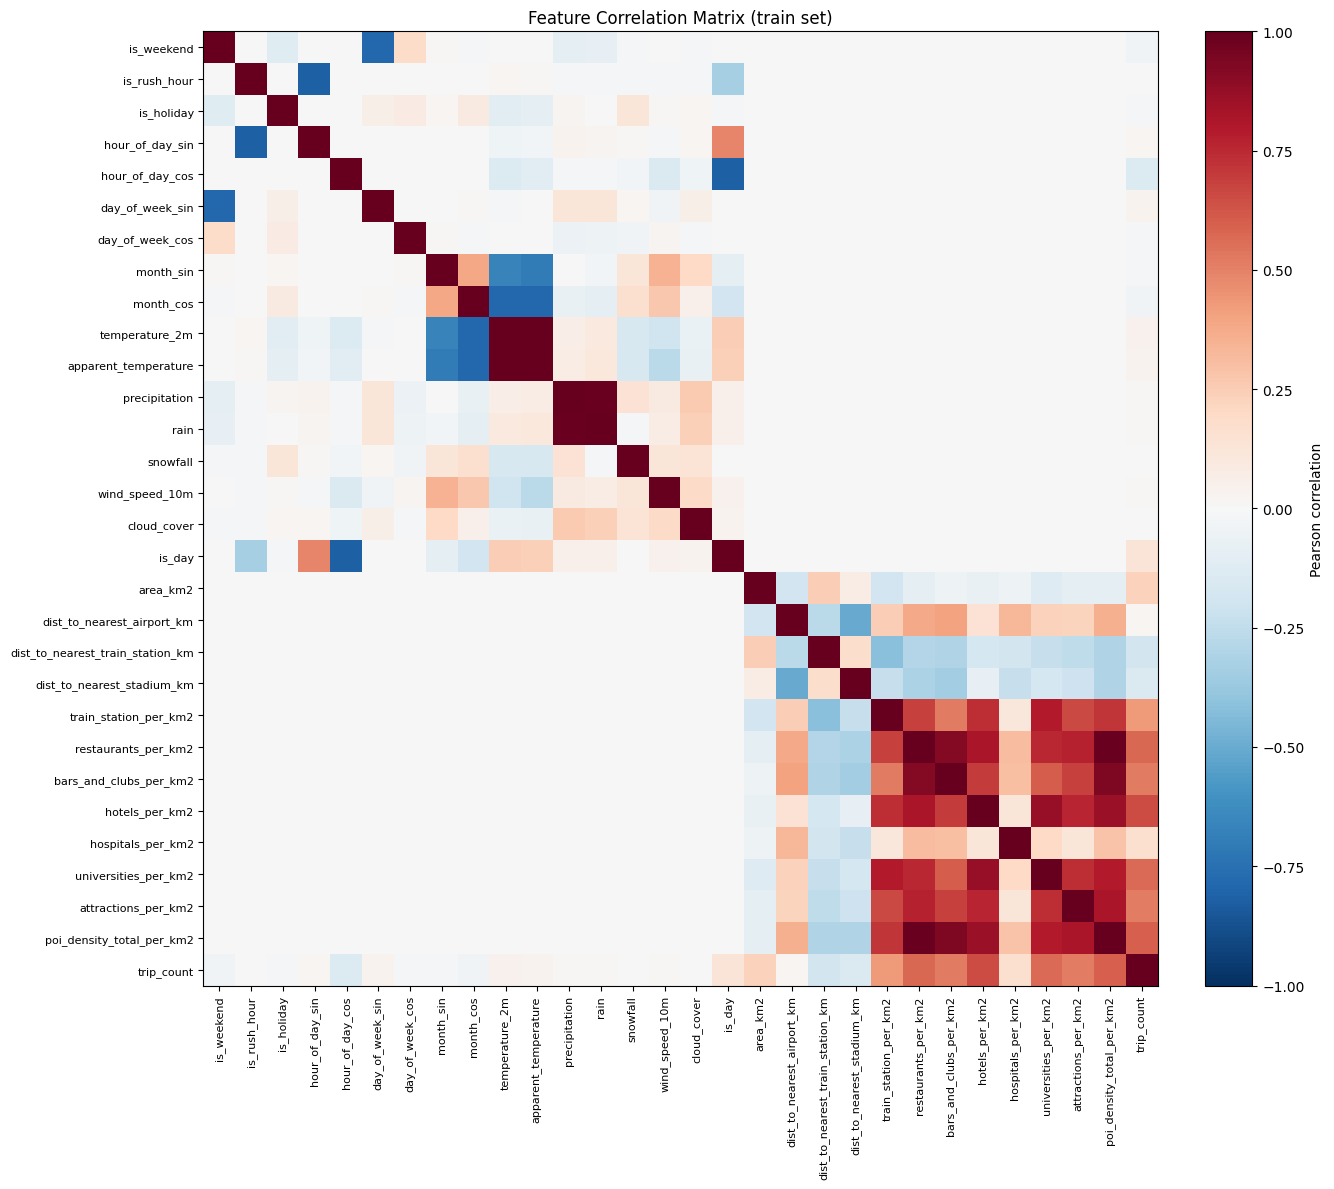

Feature pairs with |correlation| >= 0.8:
  temperature_2m                      vs apparent_temperature                 r=+0.995
  restaurants_per_km2                 vs poi_density_total_per_km2            r=+0.991
  precipitation                       vs rain                                 r=+0.986
  bars_and_clubs_per_km2              vs poi_density_total_per_km2            r=+0.930
  restaurants_per_km2                 vs bars_and_clubs_per_km2               r=+0.921
  hotels_per_km2                      vs universities_per_km2                 r=+0.871
  hotels_per_km2                      vs poi_density_total_per_km2            r=+0.866
  restaurants_per_km2                 vs hotels_per_km2                       r=+0.820
  hour_of_day_cos                     vs is_day                               r=-0.819
  attractions_per_km2                 vs poi_density_total_per_km2            r=+0.817
  is_rush_hour                        vs hour_of_day_sin                      r=-0.816


In [84]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Correlation Matrix                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import matplotlib.pyplot as plt

corr_cols   = FEATURE_COLS + [TARGET_COL]
corr_matrix = train_data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=90, fontsize=8)
ax.set_yticklabels(corr_cols, fontsize=8)

fig.colorbar(im, ax=ax, label="Pearson correlation", fraction=0.046, pad=0.04)
ax.set_title("Feature Correlation Matrix (train set)")
plt.tight_layout()
plt.show()

# Highly correlated feature pairs -> candidates for removal
THRESHOLD = 0.8
pairs = []
for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        c = corr_matrix.iloc[i, j]
        if abs(c) >= THRESHOLD:
            pairs.append((corr_cols[i], corr_cols[j], c))
pairs.sort(key=lambda x: -abs(x[2]))

print(f"Feature pairs with |correlation| >= {THRESHOLD}:")
if pairs:
    for a, b, c in pairs:
        print(f"  {a:<35s} vs {b:<35s}  r={c:+.3f}")
else:
    print("  none")

In [85]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Model-Based Feature Importance          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=0, n_jobs=-1)
rf.fit(train_data[FEATURE_COLS], train_data[TARGET_COL])

perm = permutation_importance(
    rf, train_data[FEATURE_COLS], train_data[TARGET_COL],
    n_repeats=10, random_state=0, n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature":             FEATURE_COLS,
    "rf_importance":       rf.feature_importances_,
    "perm_importance":     perm.importances_mean,
    "perm_importance_std": perm.importances_std,
}).sort_values("perm_importance", ascending=False).reset_index(drop=True)

print(importance_df.to_string(index=False))

# Features that don't measurably help (or hurt) the model when shuffled
LOW_IMPORTANCE = importance_df.loc[importance_df["perm_importance"] <= 0, "feature"].tolist()
print(f"\nFeatures with permutation importance <= 0 (no measurable contribution, or hurting the model):")
print(f"  {LOW_IMPORTANCE if LOW_IMPORTANCE else 'none'}")

                         feature  rf_importance  perm_importance  perm_importance_std
                  hotels_per_km2       0.445484         1.200271             0.011073
                          is_day       0.132865         0.227344             0.006413
                 hour_of_day_cos       0.080145         0.171198             0.003966
      dist_to_nearest_airport_km       0.089611         0.136229             0.001287
                        area_km2       0.079758         0.091131             0.001117
                 hour_of_day_sin       0.030139         0.052580             0.002270
                 day_of_week_sin       0.027250         0.047861             0.001453
      dist_to_nearest_stadium_km       0.021525         0.037130             0.000577
                      is_weekend       0.015980         0.020676             0.000589
                       month_cos       0.009198         0.015427             0.000518
                 day_of_week_cos       0.005796       

### **Final drop list**

*Applied identically across all community-area resolutions (1h / 2h / 6h / 24h) so the four models share one feature space.*

- `is_rush_hour`
- `temperature_2m`
- `apparent_temperature`
- `rain`
- `precipitation`
- `wind_speed_10m`
- `cloud_cover`
- `snowfall`
- `is_day`
- `poi_density_total_per_km2`
- `universities_per_km2`
- `restaurants_per_km2`

#### **Retained (17)**

- Temporal: `is_weekend`, `is_holiday`, `hour_of_day_sin`, `hour_of_day_cos`, `day_of_week_sin`, `day_of_week_cos`, `month_sin`, `month_cos`
- Distance: `dist_to_nearest_airport_km`, `dist_to_nearest_train_station_km`, `dist_to_nearest_stadium_km`
- POI density: `hotels_per_km2`, `bars_and_clubs_per_km2`, `attractions_per_km2`, `train_station_per_km2`, `hospitals_per_km2`
- Area: `area_km2`

#### **Cyclic hour encoding**

- `hour_of_day_sin`, `hour_of_day_cos` are the strongest predictors at fine resolution (permutation importance ≈ 0.26 / 0.12 at 1h), so they are kept for every resolution. At 24h there is exactly one row per area per day, so they are constant — inert after scaling — but retained so the feature space is identical across resolutions.
- `is_rush_hour` — dropped: weak (perm ≈ 0.007) and r=−0.82 with `hour_of_day_sin`, i.e. redundant with the cyclic encoding; constant at 24h.

#### **Weather (dropped as a block)**

- Manual testing showed removing weather improved results across the board, and the model-based importances agree (permutation importance ≈ 0.0002 – 0.007). `temperature_2m`/`apparent_temperature` (r=0.99) and `rain`/`precipitation` (r=0.99) are additionally mutually redundant.

#### **Season proxy**

- `is_day` — r=−0.96 with `month_cos` (and with `hour_of_day_cos` at sub-daily resolution); a daylight/season proxy, dropped in favour of the direct cyclic encodings.

#### **POI density cluster (r ≥ 0.8)**

- The density columns are mutually collinear (`restaurants` r=0.99 with `poi_density_total`, `bars_and_clubs` 0.93, `hotels` 0.87, `attractions` 0.82; `hotels` r=0.87 with `universities`). For community areas `hotels_per_km2` is by far the strongest POI signal (permutation importance ≈ 1.28), so we resolve the cluster by keeping the components:
    - Keep `hotels_per_km2`, `bars_and_clubs_per_km2`, `attractions_per_km2` — each carries more signal than the columns we drop
    - Drop `poi_density_total_per_km2` (linear aggregate of the components), `universities_per_km2` (r=0.87 with kept `hotels`), and `restaurants_per_km2` (r=0.92 with kept `bars_and_clubs`, lowest importance of the cluster)
    - `train_station_per_km2` and `hospitals_per_km2` are not in any r ≥ 0.8 pair, so they are retained as independent density signals
    - Note: RF importance is split across the correlated group anyway (impurity importance dilutes across collinear features), so the aggregate's rank is not evidence it is uniquely informative

In [86]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Feature Selection.                      #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

LEAKAGE_COLS = [
    'active_taxis', 'avg_idle_time', 'avg_trip_duration', 'avg_trip_distance',
    'avg_fare', 'avg_trip_total', 'avg_tip', 'tip_rate', 'share_cash_payment',
    'area_type', 'season',
]

DROP_COLS = [
    'is_rush_hour',
    'temperature_2m', 'apparent_temperature',
    'rain', 'precipitation',
    'wind_speed_10m', 'cloud_cover', 'snowfall',
    'is_day',
    'poi_density_total_per_km2',
    'universities_per_km2',
    'restaurants_per_km2',
]

RAW_CYCLIC_COLS = ['month', 'hour_of_day', 'day_of_week']
ID_COLS    = ['time_bucket', 'bucket_index', 'pickup_community_area']
TARGET_COL = 'trip_count'

FEATURE_COLS = [
    c for c in train_data.columns
    if c not in LEAKAGE_COLS + DROP_COLS + RAW_CYCLIC_COLS + ID_COLS + [TARGET_COL]
]
print(f"Numeric features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Numeric features (17): ['is_weekend', 'is_holiday', 'hour_of_day_sin', 'hour_of_day_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'area_km2', 'dist_to_nearest_airport_km', 'dist_to_nearest_train_station_km', 'dist_to_nearest_stadium_km', 'train_station_per_km2', 'bars_and_clubs_per_km2', 'hotels_per_km2', 'hospitals_per_km2', 'attractions_per_km2']


In [87]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Feature Preparation                     #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

scaler  = StandardScaler()
X_train = scaler.fit_transform(train_data[FEATURE_COLS].values)
X_val   = scaler.transform(val_data[FEATURE_COLS].values)
X_test  = scaler.transform(test_data[FEATURE_COLS].values)

IS_POISSON = (getattr(config, "LOSS", "mse") in ("poisson_nll", "nb_nll"))   # count NLLs: raw-count targets, exp inverse link

if IS_POISSON:
    y_train = train_data[TARGET_COL].values.astype(float)     # raw counts for Poisson NLL
    y_val   = val_data[TARGET_COL].values.astype(float)
else:
    y_train = np.log1p(train_data[TARGET_COL].values.astype(float))
    y_val   = np.log1p(val_data[TARGET_COL].values.astype(float))
y_test  = test_data[TARGET_COL].values.astype(float)

print(f"Target scale : {'raw counts (count NLL)' if IS_POISSON else 'log1p'}")

# community-area embedding indices — vocabulary built from the training set only;
# areas unseen in training map to a reserved "unknown" index
ca_vocab = {h: i for i, h in enumerate(sorted(train_data['pickup_community_area'].unique()))}
UNK_CA   = len(ca_vocab)
N_CA     = len(ca_vocab) + 1   # +1 for the unknown bucket

ca_train = train_data['pickup_community_area'].map(ca_vocab).astype(int).values
ca_val   = val_data['pickup_community_area'].map(ca_vocab).fillna(UNK_CA).astype(int).values
ca_test  = test_data['pickup_community_area'].map(ca_vocab).fillna(UNK_CA).astype(int).values

print(f"Unique community areas (train) : {len(ca_vocab)}  |  embed dim : {CA_EMBED_DIM}")
print(f"Unseen areas  val: {(ca_val == UNK_CA).sum()}   test: {(ca_test == UNK_CA).sum()}")
print(f"\nX_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}     y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")


Target scale : raw counts (count NLL)
Unique community areas (train) : 77  |  embed dim : 16
Unseen areas  val: 0   test: 0

X_train : (78694, 17)   y_train : (78694,)
X_val   : (16863, 17)     y_val   : (16863,)
X_test  : (16863, 17)    y_test  : (16863,)


## 3.2.8 Benchmark Models

Before diving into the three NN architectures, we evaluate two simple non-neural baselines on the held-out test set:

1. **Historical-mean predictor** — for each community area × hour-of-day pair, predict the mean `trip_count` observed in the training split. Unseen combinations fall back to the global training mean.
2. **Ridge regression** — a linear model on the same scaled feature matrix (`X_train`). Trained on log₁⁺ demand and back-transformed with `expm1` at evaluation time, matching the NN target encoding.

These numbers set the floor: any NN that cannot beat the benchmark models is not adding value for our business client. In that case the decision is fixed: the model should not be implemented and the benchmark should be chosen as their prediction model.

Metrics match the NN evaluation cells:
- **R²** — coefficient of determination
- **MAE** — mean absolute error (in raw trip counts)
- **RMSE** — root mean squared error
- **NRMSE** — RMSE normalised by mean actual demand (scale-free)
- **MAPE** — mean absolute percentage error, computed on non-zero actuals only (zero-demand rows are excluded)

In [88]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Benchmark Models                        #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

zero_demand_count = int((y_test == 0).sum())
zero_demand_pct   = 100.0 * zero_demand_count / len(y_test)
mean_actual       = float(y_test.mean())
ss_tot            = float(np.sum((y_test - mean_actual) ** 2))

print(f"Zero-demand rows : {zero_demand_count:,} / {len(y_test):,} ({zero_demand_pct:.1f}%)")
print(f"Mean actual test demand : {mean_actual:.4f}\n")


def _eval_benchmark(label, preds):
    mae   = float(np.mean(np.abs(preds - y_test)))
    rmse  = float(np.sqrt(np.mean((preds - y_test) ** 2)))
    nrmse = rmse / mean_actual if mean_actual > 0 else float("nan")
    r2    = 1.0 - float(np.sum((preds - y_test) ** 2)) / ss_tot
    nz    = y_test > 0
    mape  = 100.0 * float(np.mean(np.abs((preds[nz] - y_test[nz]) / y_test[nz])))
    print(f"{label:<35s}  R²={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}  NRMSE={nrmse:.4f}  MAPE={mape:.1f}%")
    return dict(r2=round(r2, 6), mae=round(mae, 6), rmse=round(rmse, 6), nrmse=round(nrmse, 6), mape=round(mape, 6))


# ── 1. Historical-mean predictor ───────────────────────────────────────────────
mean_table = (
    train_data.groupby(['pickup_community_area', 'hour_of_day'])['trip_count']
    .mean()
    .rename('pred_mean')
)
global_mean = float(train_data['trip_count'].mean())

test_lookup      = test_data[['pickup_community_area', 'hour_of_day']].copy()
test_lookup      = test_lookup.join(mean_table, on=['pickup_community_area', 'hour_of_day'])
hist_mean_preds  = test_lookup['pred_mean'].fillna(global_mean).values

bm_hist = _eval_benchmark("Historical mean (area × hour)", hist_mean_preds)

# ── 2. Ridge regression ────────────────────────────────────────────────────────
ridge        = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)            # y_train is raw counts (Poisson) or log1p-transformed
ridge_preds  = ridge.predict(X_test) if IS_POISSON else np.expm1(ridge.predict(X_test))
ridge_preds  = np.maximum(ridge_preds, 0.0)   # clamp to non-negative

bm_ridge = _eval_benchmark("Ridge regression", ridge_preds)


Zero-demand rows : 3,058 / 16,863 (18.1%)
Mean actual test demand : 45.1777



Historical mean (area × hour)        R²=0.8458  MAE=17.8702  RMSE=72.6765  NRMSE=1.6087  MAPE=85.2%
Ridge regression                     R²=0.6083  MAE=40.6983  RMSE=115.8456  NRMSE=2.5642  MAPE=585.8%


## Embed Dimension Search

Since `embed_dim` is independent of architecture depth and width, we search it once on
the baseline and fix the winner for all three models.

Candidates: `[8, 16, 32]` — 3 runs total (with early stopping).

In [89]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Embed Dimension Search                  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

EMBED_CANDIDATES = [8, 16, 32]
EMBED_SEARCH_MAX_EPOCHS = 50   # shorter budget: the search only ranks embed dims, not train to convergence (model training keeps config.MAX_EPOCHS)

print(f"Embed search — ARCH_BASELINE, seed={HP_SEARCH_SEEDS[0]}, patience={HP_PATIENCE}, max_epochs={EMBED_SEARCH_MAX_EPOCHS}\n")
embed_results = []
_full_max_epochs, config.MAX_EPOCHS = config.MAX_EPOCHS, EMBED_SEARCH_MAX_EPOCHS   # temporarily shorten
try:
    for emb in EMBED_CANDIDATES:
        _, val_loss, _ = train_model(
            ARCH_BASELINE, X_train, y_train, X_val, y_val,
            ca_train, ca_val,
            seed=HP_SEARCH_SEEDS[0], device=device, verbose=False,
            lr=config.LEARNING_RATE, embed_dim=emb, patience=HP_PATIENCE,
        )
        embed_results.append((emb, val_loss))
        print(f"  embed_dim={emb:>3}  val_loss={val_loss:.4f}")
finally:
    config.MAX_EPOCHS = _full_max_epochs   # restore full budget for model training

best_embed_dim = min(embed_results, key=lambda x: x[1])[0]
CA_EMBED_DIM        = best_embed_dim
config.CA_EMBED_DIM = best_embed_dim
print(f"\nBest embed_dim: {CA_EMBED_DIM}  →  set as global CA_EMBED_DIM")

Embed search — ARCH_BASELINE, seed=0, patience=5, max_epochs=50

  embed_dim=  8  val_loss=3.2543
  embed_dim= 16  val_loss=3.3181
  embed_dim= 32  val_loss=3.3123

Best embed_dim: 8  →  set as global CA_EMBED_DIM


## 3.2.9 Baseline Model — Training

Run `ARCH_BASELINE = (2 hidden layers, 64 units)` and report
the validation loss.


In [44]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Visualization          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

input_dim = X_train.shape[1]
n_layers, width = ARCH_BASELINE

viz_model = DemandBaseline(input_dim, n_layers, width, N_CA, CA_EMBED_DIM)
x_dummy   = torch.zeros(1, input_dim)
c_dummy   = torch.zeros(1, dtype=torch.long)
summary(viz_model, input_data=(x_dummy, c_dummy), col_names=["input_size", "output_size", "num_params"], verbose=1)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 17]                   [1]                       1
├─Embedding: 1-1                         [1]                       [1, 32]                   2,496
├─Sequential: 1-2                        [1, 49]                   [1, 1]                    --
│    └─Linear: 2-1                       [1, 49]                   [1, 64]                   3,200
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
Total params: 9,922
Trainable params: 9,922
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
DemandBaseline                           [1, 17]                   [1]                       1
├─Embedding: 1-1                         [1]                       [1, 32]                   2,496
├─Sequential: 1-2                        [1, 49]                   [1, 1]                    --
│    └─Linear: 2-1                       [1, 49]                   [1, 64]                   3,200
│    └─ReLU: 2-2                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-3                       [1, 64]                   [1, 64]                   4,160
│    └─ReLU: 2-4                         [1, 64]                   [1, 64]                   --
│    └─Linear: 2-5                       [1, 64]                   [1, 1]                    65
Total params: 9,922
Trainable params: 9,922
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB)

In [45]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

print(f"Device: {device}\n")

baseline_train_losses = []
baseline_val_losses   = []
baseline_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=seed, device=device,
    )
    baseline_train_losses.append(train_loss)
    baseline_val_losses.append(val_loss)
    baseline_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(baseline_train_losses):.4f} \u00b1 {np.std(baseline_train_losses):.4f}  val: {np.mean(baseline_val_losses):.4f} \u00b1 {np.std(baseline_val_losses):.4f}")

Device: cpu

Epoch   1/200
  loss: 5.5478  val_loss: 3.6399 ✓
Epoch   2/200
  loss: 3.7402  val_loss: 3.5825 ✓
Epoch   3/200
  loss: 3.6901  val_loss: 3.5521 ✓
Epoch   4/200
  loss: 3.6553  val_loss: 3.5291 ✓
Epoch   5/200
  loss: 3.6277  val_loss: 3.5104 ✓
Epoch   6/200
  loss: 3.6054  val_loss: 3.4949 ✓
Epoch   7/200
  loss: 3.5872  val_loss: 3.4819 ✓
Epoch   8/200
  loss: 3.5719  val_loss: 3.4709 ✓
Epoch   9/200
  loss: 3.5582  val_loss: 3.4612 ✓
Epoch  10/200
  loss: 3.5471  val_loss: 3.4528 ✓
Epoch  11/200
  loss: 3.5374  val_loss: 3.4454 ✓
Epoch  12/200
  loss: 3.5284  val_loss: 3.4388 ✓
Epoch  13/200
  loss: 3.5206  val_loss: 3.4329 ✓
Epoch  14/200
  loss: 3.5141  val_loss: 3.4273 ✓
Epoch  15/200
  loss: 3.5073  val_loss: 3.4224 ✓
Epoch  16/200
  loss: 3.5013  val_loss: 3.4176 ✓
Epoch  17/200
  loss: 3.4957  val_loss: 3.4133 ✓
Epoch  18/200
  loss: 3.4903  val_loss: 3.4093 ✓
Epoch  19/200
  loss: 3.4857  val_loss: 3.4055 ✓
Epoch  20/200
  loss: 3.4808  val_loss: 3.4016 ✓
Epoch  

### 3.2.9 Baseline Model — Evaluation

In [46]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Baseline Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_BASELINE, baseline_models, baseline_train_losses, baseline_val_losses,
    X_test, y_test, ca_test,
    device=device,
    show_weight_stats=True,
)

Zero-demand rows: 3,058 / 16,863 (18.1%)
Mean actual test demand : 45.1777  (min=0.0000, max=2541.0000)

  seed=0 layer weight stats:
    ca_embed.weight  shape=(78, 32)      max|w|=0.2823  mean|w|=0.0213  norm=1.6430
    net.0.weight    shape=(64, 49)      max|w|=0.8925  mean|w|=0.1612  norm=11.3428
    net.2.weight    shape=(64, 64)      max|w|=0.6858  mean|w|=0.1424  norm=11.4302
    net.4.weight    shape=(1, 64)       max|w|=0.6427  mean|w|=0.1790  norm=1.8404
  seed=0  R²=0.6269  MAE=23.1462  NRMSE=2.5027  MAPE=75.2%  | zeros 472/3,058  false=138  | pred min=0.1 max=3398.8

--- original scale ---
Baseline  R²    : 0.6269 ± 0.0000
Baseline  MAE   : 23.1462 ± 0.0000
Baseline  RMSE  : 113.0677 ± 0.0000
Baseline  NRMSE : 2.5027 ± 0.0000
Baseline  MAPE  : 75.23% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Baseline  Correct-zero : 472.0 ± 0.0  (out of 3,058)
Baseline  False-zero   : 138.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Baseline  Pred

In [47]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_6h.csv (28 columns)
          timestamp loss    model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae       rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation training_loss  weight_decay      mape
2026-07-23T22:35:40  NaN baseline         2     64        0.00005         512     0   2.84392               3058    45.177667 0.626883 23.146208 113.067712 2.502735 0.837398 0.506788   0.64246   0.353641           472         138  0.130793 3398.823242                   NaN              relu        nb_nll           0.0 75.231423


## 3.2.10 Hyperparameter Search — Baseline Model



In [48]:
run_hp_search_2step(
    ARCH_BASELINE,
    X_train, y_train, X_val, y_val,
    ca_train, ca_val,
    device=device,
)

=== Step 1/2 — decade grid (baseline) ===

HP Search — baseline  |  grid 12×4 = 48 combos  |  seeds=(0,)  |  patience=5

   #          lr          wd    mean val  state
--------------------------------------------------
   1    5.00e-05    5.00e-04      2.8439  complete
   2    5.00e-07    0.00e+00      3.5768  complete
   3    2.00e-05    5.00e-03      3.2239  complete
   4    5.00e-05    5.00e-03      2.8448  complete
   5    8.00e-05    0.00e+00      2.7733  complete
   6    2.00e-04    5.00e-04      2.7736  complete
   7    8.00e-05    5.00e-03      2.7551  complete
   8    5.00e-04    0.00e+00      2.7553  complete
   9    5.00e-07    5.00e-02      9.5152  pruned
  10    8.00e-07    5.00e-03      7.1785  pruned
  11    8.00e-07    5.00e-02      7.1834  pruned
  12    5.00e-05    5.00e-02      3.4963  pruned
  13    8.00e-05    5.00e-04      2.7720  complete
  14    2.00e-05    5.00e-02      3.5663  pruned
  15    8.00e-04    5.00e-02      2.7075  complete
  16    2.00e-07    5.00e

{'lr': 0.0009, 'weight_decay': 0.03}

### 3.2.10 Tuned Baseline — Training

Re-train the baseline architecture with the best hyperparameters found above.


In [49]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_BASELINE]
print(f"Best HP: {hp}\n")

tuned_train_losses = []
tuned_val_losses   = []
tuned_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_BASELINE, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
        test_data=(X_test, y_test if IS_POISSON else np.log1p(y_test), ca_test),
    )
    tuned_train_losses.append(train_loss)
    tuned_val_losses.append(val_loss)
    tuned_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_BASELINE, "baseline")
print(f"\n{arch_label}  train: {np.mean(tuned_train_losses):.4f} \u00b1 {np.std(tuned_train_losses):.4f}  val: {np.mean(tuned_val_losses):.4f} \u00b1 {np.std(tuned_val_losses):.4f}")

Best HP: {'lr': 0.0009, 'weight_decay': 0.03}

Epoch   1/200
  loss: 4.2920  val_loss: 3.4799 ✓
Epoch   2/200
  loss: 3.5269  val_loss: 3.4049 ✓
Epoch   3/200
  loss: 3.4528  val_loss: 3.3567 ✓
Epoch   4/200
  loss: 3.3995  val_loss: 3.3117 ✓
Epoch   5/200
  loss: 3.3509  val_loss: 3.2699 ✓
Epoch   6/200
  loss: 3.3029  val_loss: 3.2236 ✓
Epoch   7/200
  loss: 3.2524  val_loss: 3.1762 ✓
Epoch   8/200
  loss: 3.1977  val_loss: 3.1240 ✓
Epoch   9/200
  loss: 3.1383  val_loss: 3.0699 ✓
Epoch  10/200
  loss: 3.0751  val_loss: 3.0111 ✓
Epoch  11/200
  loss: 3.0107  val_loss: 2.9562 ✓
Epoch  12/200
  loss: 2.9464  val_loss: 2.9006 ✓
Epoch  13/200
  loss: 2.8854  val_loss: 2.8497 ✓
Epoch  14/200
  loss: 2.8303  val_loss: 2.8185 ✓
Epoch  15/200
  loss: 2.7827  val_loss: 2.7923 ✓
Epoch  16/200
  loss: 2.7445  val_loss: 2.7636 ✓
Epoch  17/200
  loss: 2.7153  val_loss: 2.7638  (no improvement 1/10)
Epoch  18/200
  loss: 2.6926  val_loss: 2.7401 ✓
Epoch  19/200
  loss: 2.6753  val_loss: 2.7363 ✓
E

### 3.2.10 Tuned Baseline — Evaluation

Evaluate on the held-out **test set** and compare against the untuned baseline.


In [50]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Baseline — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_BASELINE, tuned_models, tuned_train_losses, tuned_val_losses,
    X_test, y_test, ca_test,
    device=device, label="Tuned Baseline", model_name="baseline_tuned",
    hp=BEST_HP[ARCH_BASELINE],
)

Zero-demand rows: 3,058 / 16,863 (18.1%)
Mean actual test demand : 45.1777  (min=0.0000, max=2541.0000)

  seed=0  R²=0.8399  MAE=16.3500  NRMSE=1.6392  MAPE=67.0%  | zeros 625/3,058  false=203  | pred min=0.3 max=1645.0

--- original scale ---
Tuned Baseline  R²    : 0.8399 ± 0.0000
Tuned Baseline  MAE   : 16.3500 ± 0.0000
Tuned Baseline  RMSE  : 74.0550 ± 0.0000
Tuned Baseline  NRMSE : 1.6392 ± 0.0000
Tuned Baseline  MAPE  : 67.02% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Tuned Baseline  Correct-zero : 625.0 ± 0.0  (out of 3,058)
Tuned Baseline  False-zero   : 203.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Tuned Baseline  Pred min : 0.2664 ± 0.0000
Tuned Baseline  Pred max : 1645.0424 ± 0.0000  (actual max: 2541.0000)

--- overfitting check (nb_nll, raw counts) ---
               train       val      test
  seed=0       2.5923    2.6799    2.6549


In [51]:
results_df

,timestamp,training_loss,model,n_layers,width,learning_rate,weight_decay,batch_size,seed,hidden_activation,...,nrmse,mape,r2_log,mae_log,rmse_log,nrmse_log,correct_zero,false_zero,pred_min,pred_max
0,2026-07-23T22:35:40,nb_nll,baseline,2,64,0.00005,0.0,512,0,relu,...,2.502735,75.231423,0.837398,0.506788,0.64246,0.353641,472,138,0.130793,3398.823242


In [52]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_6h.csv (28 columns)
          timestamp loss          model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae   rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation training_loss  weight_decay      mape
2026-07-23T22:56:46  NaN baseline_tuned         2     64         0.0009         512     0  2.679894               3058    45.177667 0.839942 16.349999 74.055 1.639195 0.870561  0.45317  0.573213   0.315524           625         203  0.266381 1645.042358                   NaN              relu        nb_nll          0.03 67.022274


## 3.2.11 Deeper Model — Training

Run `ARCH_DEEPER = (8 hidden layers, 64 units)`.
Width is fixed; depth increased (x4) relative to the baseline.


In [53]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

deeper_train_losses = []
deeper_val_losses   = []
deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=seed, device=device,
    )
    deeper_train_losses.append(train_loss)
    deeper_val_losses.append(val_loss)
    deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(deeper_train_losses):.4f} \u00b1 {np.std(deeper_train_losses):.4f}  val: {np.mean(deeper_val_losses):.4f} \u00b1 {np.std(deeper_val_losses):.4f}")

Epoch   1/200
  loss: 4.2416  val_loss: 3.7315 ✓
Epoch   2/200
  loss: 3.7726  val_loss: 3.6281 ✓
Epoch   3/200
  loss: 3.6802  val_loss: 3.5653 ✓
Epoch   4/200
  loss: 3.6263  val_loss: 3.5301 ✓
Epoch   5/200
  loss: 3.5895  val_loss: 3.4966 ✓
Epoch   6/200
  loss: 3.5622  val_loss: 3.4808 ✓
Epoch   7/200
  loss: 3.5411  val_loss: 3.4619 ✓
Epoch   8/200
  loss: 3.5239  val_loss: 3.4474 ✓
Epoch   9/200
  loss: 3.5095  val_loss: 3.4352 ✓
Epoch  10/200
  loss: 3.4967  val_loss: 3.4247 ✓
Epoch  11/200
  loss: 3.4857  val_loss: 3.4142 ✓
Epoch  12/200
  loss: 3.4750  val_loss: 3.4044 ✓
Epoch  13/200
  loss: 3.4660  val_loss: 3.3994 ✓
Epoch  14/200
  loss: 3.4577  val_loss: 3.3894 ✓
Epoch  15/200
  loss: 3.4500  val_loss: 3.3840 ✓
Epoch  16/200
  loss: 3.4419  val_loss: 3.3787 ✓
Epoch  17/200
  loss: 3.4347  val_loss: 3.3723 ✓
Epoch  18/200
  loss: 3.4275  val_loss: 3.3644 ✓
Epoch  19/200
  loss: 3.4205  val_loss: 3.3624 ✓
Epoch  20/200
  loss: 3.4141  val_loss: 3.3549 ✓
Epoch  21/200
  loss

### 3.2.11 Deeper Model — Evaluation

In [54]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Deeper   Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_DEEPER, deeper_models, deeper_train_losses, deeper_val_losses,
    X_test, y_test, ca_test,
    device=device,
)

Zero-demand rows: 3,058 / 16,863 (18.1%)
Mean actual test demand : 45.1777  (min=0.0000, max=2541.0000)

  seed=0  R²=0.7374  MAE=20.8153  NRMSE=2.0994  MAPE=73.4%  | zeros 906/3,058  false=368  | pred min=0.1 max=1759.7

--- original scale ---
Deep  R²    : 0.7374 ± 0.0000
Deep  MAE   : 20.8153 ± 0.0000
Deep  RMSE  : 94.8471 ± 0.0000
Deep  NRMSE : 2.0994 ± 0.0000
Deep  MAPE  : 73.40% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Deep  Correct-zero : 906.0 ± 0.0  (out of 3,058)
Deep  False-zero   : 368.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Deep  Pred min : 0.1460 ± 0.0000
Deep  Pred max : 1759.7241 ± 0.0000  (actual max: 2541.0000)

--- overfitting check (nb_nll, raw counts) ---
               train       val      test
  seed=0       2.6970    2.8032    2.7656


In [55]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_6h.csv (28 columns)
          timestamp loss model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2      mae      rmse    nrmse  r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation training_loss  weight_decay      mape
2026-07-23T22:58:25  NaN  deep         8     64        0.00005         512     0   2.80322               3058    45.177667 0.737447 20.81527 94.847094 2.099424 0.84805 0.491239  0.621061   0.341861           906         368  0.146014 1759.724121                   NaN              relu        nb_nll           0.0 73.398021


## 3.2.12 Hyperparameter Search — Deeper Model

In [56]:
run_hp_search_2step(
    ARCH_DEEPER,
    X_train, y_train, X_val, y_val,
    ca_train, ca_val,
    device=device,
)

=== Step 1/2 — decade grid (deep) ===

HP Search — deep  |  grid 12×4 = 48 combos  |  seeds=(0,)  |  patience=5

   #          lr          wd    mean val  state
--------------------------------------------------
   1    5.00e-05    5.00e-04      2.8017  complete
   2    5.00e-07    0.00e+00      3.6226  complete
   3    2.00e-05    5.00e-03      3.0861  complete
   4    5.00e-05    5.00e-03      2.8196  complete
   5    8.00e-05    0.00e+00      2.7849  complete
   6    2.00e-04    5.00e-04      2.7705  complete
   7    8.00e-05    5.00e-03      2.7858  complete
   8    5.00e-04    0.00e+00      2.7583  complete
   9    5.00e-07    5.00e-02      4.3371  pruned
  10    8.00e-07    5.00e-03      4.1857  pruned
  11    8.00e-07    5.00e-02      4.1863  pruned
  12    5.00e-05    5.00e-02      3.4775  pruned
  13    8.00e-05    5.00e-04      2.8188  complete
  14    2.00e-05    5.00e-02      3.5970  pruned
  15    8.00e-04    5.00e-02      2.6950  complete
  16    2.00e-07    5.00e-03     

{'lr': 0.0008, 'weight_decay': 0.04}

### 3.2.12 Tuned Deeper — Training

Re-train the deeper architecture with the best hyperparameters found above.

In [57]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Training                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_DEEPER]
print(f"Best HP: {hp}\n")

tuned_deeper_train_losses = []
tuned_deeper_val_losses   = []
tuned_deeper_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_DEEPER, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
        test_data=(X_test, y_test if IS_POISSON else np.log1p(y_test), ca_test),
    )
    tuned_deeper_train_losses.append(train_loss)
    tuned_deeper_val_losses.append(val_loss)
    tuned_deeper_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_DEEPER, "deep")
print(f"\n{arch_label}  train: {np.mean(tuned_deeper_train_losses):.4f} ± {np.std(tuned_deeper_train_losses):.4f}  val: {np.mean(tuned_deeper_val_losses):.4f} ± {np.std(tuned_deeper_val_losses):.4f}")

Best HP: {'lr': 0.0008, 'weight_decay': 0.04}

Epoch   1/200
  loss: 3.7418  val_loss: 3.4019 ✓
Epoch   2/200
  loss: 3.4250  val_loss: 3.3244 ✓
Epoch   3/200
  loss: 3.3456  val_loss: 3.2446 ✓
Epoch   4/200
  loss: 3.2686  val_loss: 3.1744 ✓
Epoch   5/200
  loss: 3.1946  val_loss: 3.1124 ✓
Epoch   6/200
  loss: 3.1264  val_loss: 3.0554 ✓
Epoch   7/200
  loss: 3.0652  val_loss: 3.0117 ✓
Epoch   8/200
  loss: 3.0058  val_loss: 2.9580 ✓
Epoch   9/200
  loss: 2.9456  val_loss: 2.9132 ✓
Epoch  10/200
  loss: 2.8843  val_loss: 2.8638 ✓
Epoch  11/200
  loss: 2.8270  val_loss: 2.8176 ✓
Epoch  12/200
  loss: 2.7801  val_loss: 2.7921 ✓
Epoch  13/200
  loss: 2.7452  val_loss: 2.7902 ✓
Epoch  14/200
  loss: 2.7173  val_loss: 2.7667 ✓
Epoch  15/200
  loss: 2.6949  val_loss: 2.7495 ✓
Epoch  16/200
  loss: 2.6759  val_loss: 2.7603  (no improvement 1/10)
Epoch  17/200
  loss: 2.6620  val_loss: 2.7722  (no improvement 2/10)
Epoch  18/200
  loss: 2.6502  val_loss: 2.7612  (no improvement 3/10)
Epoch  1

### 3.2.12 Tuned Deeper — Evaluation

Evaluate on the held-out **test set** and compare against the untuned deeper model.

In [58]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Deeper — Evaluation               #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_DEEPER, tuned_deeper_models, tuned_deeper_train_losses, tuned_deeper_val_losses,
    X_test, y_test, ca_test,
    device=device, label="Tuned Deeper", model_name="deep_tuned",
    hp=BEST_HP[ARCH_DEEPER],
)

Zero-demand rows: 3,058 / 16,863 (18.1%)
Mean actual test demand : 45.1777  (min=0.0000, max=2541.0000)

  seed=0  R²=0.8145  MAE=17.4308  NRMSE=1.7648  MAPE=65.0%  | zeros 0/3,058  false=0  | pred min=0.6 max=1447.7

--- original scale ---
Tuned Deeper  R²    : 0.8145 ± 0.0000
Tuned Deeper  MAE   : 17.4308 ± 0.0000
Tuned Deeper  RMSE  : 79.7308 ± 0.0000
Tuned Deeper  NRMSE : 1.7648 ± 0.0000
Tuned Deeper  MAPE  : 65.01% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Tuned Deeper  Correct-zero : 0.0 ± 0.0  (out of 3,058)
Tuned Deeper  False-zero   : 0.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Tuned Deeper  Pred min : 0.6450 ± 0.0000
Tuned Deeper  Pred max : 1447.7463 ± 0.0000  (actual max: 2541.0000)

--- overfitting check (nb_nll, raw counts) ---
               train       val      test
  seed=0       2.5781    2.6860    2.6675


In [59]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_6h.csv (28 columns)
          timestamp loss      model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae     rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation training_loss  weight_decay      mape
2026-07-23T23:20:15  NaN deep_tuned         8     64         0.0008         512     0  2.685958               3058    45.177667 0.814467 17.430783 79.73081 1.764828 0.872491  0.45361  0.568922   0.313162             0           0  0.644966 1447.746338                   NaN              relu        nb_nll          0.04 65.009213


## 3.2.13 Wider Model — Training

Run `ARCH_WIDER = (2 hidden layers, 256 units)`.
Depth is fixed; width increased (x4) relative to the baseline.


In [60]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Training              #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

wider_train_losses = []
wider_val_losses   = []
wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=seed, device=device,
    )
    wider_train_losses.append(train_loss)
    wider_val_losses.append(val_loss)
    wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(wider_train_losses):.4f} \u00b1 {np.std(wider_train_losses):.4f}  val: {np.mean(wider_val_losses):.4f} \u00b1 {np.std(wider_val_losses):.4f}")

Epoch   1/200
  loss: 5.3900  val_loss: 4.0407 ✓
Epoch   2/200
  loss: 3.9766  val_loss: 3.8252 ✓
Epoch   3/200
  loss: 3.8379  val_loss: 3.7164 ✓
Epoch   4/200
  loss: 3.7499  val_loss: 3.6435 ✓
Epoch   5/200
  loss: 3.6880  val_loss: 3.5897 ✓
Epoch   6/200
  loss: 3.6420  val_loss: 3.5481 ✓
Epoch   7/200
  loss: 3.6054  val_loss: 3.5146 ✓
Epoch   8/200
  loss: 3.5751  val_loss: 3.4866 ✓
Epoch   9/200
  loss: 3.5493  val_loss: 3.4629 ✓
Epoch  10/200
  loss: 3.5275  val_loss: 3.4435 ✓
Epoch  11/200
  loss: 3.5085  val_loss: 3.4265 ✓
Epoch  12/200
  loss: 3.4926  val_loss: 3.4124 ✓
Epoch  13/200
  loss: 3.4786  val_loss: 3.4004 ✓
Epoch  14/200
  loss: 3.4667  val_loss: 3.3903 ✓
Epoch  15/200
  loss: 3.4565  val_loss: 3.3815 ✓
Epoch  16/200
  loss: 3.4471  val_loss: 3.3736 ✓
Epoch  17/200
  loss: 3.4389  val_loss: 3.3658 ✓
Epoch  18/200
  loss: 3.4308  val_loss: 3.3588 ✓
Epoch  19/200
  loss: 3.4234  val_loss: 3.3517 ✓
Epoch  20/200
  loss: 3.4163  val_loss: 3.3453 ✓
Epoch  21/200
  loss

### 3.2.13 Wider Model — Evaluation

In [61]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Wider    Model — Evaluation             #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_WIDER, wider_models, wider_train_losses, wider_val_losses,
    X_test, y_test, ca_test,
    device=device,
)

Zero-demand rows: 3,058 / 16,863 (18.1%)
Mean actual test demand : 45.1777  (min=0.0000, max=2541.0000)

  seed=0  R²=0.7293  MAE=20.7299  NRMSE=2.1319  MAPE=76.4%  | zeros 673/3,058  false=215  | pred min=0.1 max=2732.0

--- original scale ---
Wide  R²    : 0.7293 ± 0.0000
Wide  MAE   : 20.7299 ± 0.0000
Wide  RMSE  : 96.3124 ± 0.0000
Wide  NRMSE : 2.1319 ± 0.0000
Wide  MAPE  : 76.44% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Wide  Correct-zero : 673.0 ± 0.0  (out of 3,058)
Wide  False-zero   : 215.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Wide  Pred min : 0.1059 ± 0.0000
Wide  Pred max : 2731.9666 ± 0.0000  (actual max: 2541.0000)

--- overfitting check (nb_nll, raw counts) ---
               train       val      test
  seed=0       2.6746    2.7910    2.7446


In [62]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_6h.csv (28 columns)
          timestamp loss model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae     rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation training_loss  weight_decay    mape
2026-07-23T23:21:50  NaN  wide         2    256        0.00005         512     0  2.790966               3058    45.177667 0.729272 20.729904 96.31243 2.131859 0.843715 0.497631  0.629858   0.346704           673         215  0.105932 2731.966553                   NaN              relu        nb_nll           0.0 76.4374


## 3.2.14 Hyperparameter Search — Wider Model


In [63]:
run_hp_search_2step(
    ARCH_WIDER,
    X_train, y_train, X_val, y_val,
    ca_train, ca_val,
    device=device,
)

=== Step 1/2 — decade grid (wide) ===

HP Search — wide  |  grid 12×4 = 48 combos  |  seeds=(0,)  |  patience=5

   #          lr          wd    mean val  state
--------------------------------------------------
   1    5.00e-05    5.00e-04      2.7907  complete
   2    5.00e-07    0.00e+00      3.5964  complete
   3    2.00e-05    5.00e-03      3.1070  complete
   4    5.00e-05    5.00e-03      2.7896  complete
   5    8.00e-05    0.00e+00      2.7812  complete
   6    2.00e-04    5.00e-04      2.7727  complete
   7    8.00e-05    5.00e-03      2.7684  complete
   8    5.00e-04    0.00e+00         inf  complete
   9    5.00e-07    5.00e-02      4.4682  pruned
  10    8.00e-07    5.00e-03      4.1298  pruned
  11    8.00e-07    5.00e-02      4.1309  pruned
  12    5.00e-05    5.00e-02      3.5154  pruned
  13    8.00e-05    5.00e-04      2.7804  complete
  14    2.00e-05    5.00e-02      3.6743  pruned
  15    8.00e-04    5.00e-02         inf  complete
  16    2.00e-07    5.00e-03     

{'lr': 0.0003, 'weight_decay': 0.06}

### 3.2.14 Tuned Wider — Training

Re-train the wider architecture with the best hyperparameters found above.

In [64]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Training                 #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

hp = BEST_HP[ARCH_WIDER]
print(f"Best HP: {hp}\n")

tuned_wider_train_losses = []
tuned_wider_val_losses   = []
tuned_wider_models      = []

for seed in SEEDS:
    model, val_loss, train_loss = train_model(
        ARCH_WIDER, X_train, y_train, X_val, y_val,
        ca_train, ca_val,
        seed=seed, device=device,
        lr=hp["lr"],
        weight_decay=hp.get("weight_decay", 0.0),
        test_data=(X_test, y_test if IS_POISSON else np.log1p(y_test), ca_test),
    )
    tuned_wider_train_losses.append(train_loss)
    tuned_wider_val_losses.append(val_loss)
    tuned_wider_models.append(model)

arch_label = ARCH_NAMES.get(ARCH_WIDER, "wide")
print(f"\n{arch_label}  train: {np.mean(tuned_wider_train_losses):.4f} \u00b1 {np.std(tuned_wider_train_losses):.4f}  val: {np.mean(tuned_wider_val_losses):.4f} \u00b1 {np.std(tuned_wider_val_losses):.4f}")

Best HP: {'lr': 0.0003, 'weight_decay': 0.06}

Epoch   1/200
  loss: 5.6590  val_loss: 3.7670 ✓
Epoch   2/200
  loss: 3.7730  val_loss: 3.6192 ✓
Epoch   3/200
  loss: 3.6531  val_loss: 3.5356 ✓
Epoch   4/200
  loss: 3.5773  val_loss: 3.4740 ✓
Epoch   5/200
  loss: 3.5203  val_loss: 3.4293 ✓
Epoch   6/200
  loss: 3.4774  val_loss: 3.3935 ✓
Epoch   7/200
  loss: 3.4445  val_loss: 3.3646 ✓
Epoch   8/200
  loss: 3.4170  val_loss: 3.3400 ✓
Epoch   9/200
  loss: 3.3940  val_loss: 3.3212 ✓
Epoch  10/200
  loss: 3.3751  val_loss: 3.3073 ✓
Epoch  11/200
  loss: 3.3587  val_loss: 3.2924 ✓
Epoch  12/200
  loss: 3.3447  val_loss: 3.2809 ✓
Epoch  13/200
  loss: 3.3314  val_loss: 3.2676 ✓
Epoch  14/200
  loss: 3.3192  val_loss: 3.2581 ✓
Epoch  15/200
  loss: 3.3072  val_loss: 3.2474 ✓
Epoch  16/200
  loss: 3.2958  val_loss: 3.2389 ✓
Epoch  17/200
  loss: 3.2850  val_loss: 3.2283 ✓
Epoch  18/200
  loss: 3.2740  val_loss: 3.2202 ✓
Epoch  19/200
  loss: 3.2634  val_loss: 3.2090 ✓
Epoch  20/200
  loss: 

### 3.2.14 Tuned Wider — Evaluation

Evaluate on the held-out **test set** and compare against the untuned wider model.

In [65]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Tuned Wider — Evaluation                #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

run_results = evaluate_models(
    ARCH_WIDER, tuned_wider_models, tuned_wider_train_losses, tuned_wider_val_losses,
    X_test, y_test, ca_test,
    device=device, label="Tuned Wider", model_name="wider_tuned",
    hp=BEST_HP[ARCH_WIDER],
)

Zero-demand rows: 3,058 / 16,863 (18.1%)
Mean actual test demand : 45.1777  (min=0.0000, max=2541.0000)

  seed=0  R²=0.8072  MAE=17.5580  NRMSE=1.7988  MAPE=65.4%  | zeros 0/3,058  false=0  | pred min=0.5 max=1400.3

--- original scale ---
Tuned Wider  R²    : 0.8072 ± 0.0000
Tuned Wider  MAE   : 17.5580 ± 0.0000
Tuned Wider  RMSE  : 81.2675 ± 0.0000
Tuned Wider  NRMSE : 1.7988 ± 0.0000
Tuned Wider  MAPE  : 65.42% ± 0.00%  (non-zero actuals only)

--- zero-demand ---
Tuned Wider  Correct-zero : 0.0 ± 0.0  (out of 3,058)
Tuned Wider  False-zero   : 0.0 ± 0.0  (predicted 0 when demand > 0)

--- prediction range (raw scale) ---
Tuned Wider  Pred min : 0.5146 ± 0.0000
Tuned Wider  Pred max : 1400.2576 ± 0.0000  (actual max: 2541.0000)

--- overfitting check (nb_nll, raw counts) ---
               train       val      test
  seed=0       2.6481    2.7034    2.6427


In [66]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Save Results                            #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

results_df = save_results(run_results)

Appended 1 rows to data/results/nn_results_ca_6h.csv (28 columns)
          timestamp loss       model  n_layers  width  learning_rate  batch_size  seed  val_loss  zero_demand_count  mean_actual       r2       mae      rmse    nrmse   r2_log  mae_log  rmse_log  nrmse_log  correct_zero  false_zero  pred_min    pred_max  overfitting_measures hidden_activation training_loss  weight_decay      mape
2026-07-23T23:39:28  NaN wider_tuned         2    256         0.0003         512     0   2.70339               3058    45.177667 0.807247 17.558008 81.267468 1.798842 0.867854 0.459154  0.579176   0.318806             0           0  0.514639 1400.257568                   NaN              relu        nb_nll          0.06 65.419065


## 3.2.15 Visualization: Trip Count Distribution

Histogram of `trip_count` across the full dataset, on the raw scale, the
`log1p` scale, and the per-observation Poisson negative log-likelihood at
the empirical mean rate λ̂ — to illustrate the skew discussed above and
how well a Poisson assumption fits the data.

Empirical mean (lambda_hat) : 47.7616
Empirical variance          : 33815.4617
Dispersion (var / mean)     : 708.0056  (overdispersed)
Mean Poisson NLL @ lambda_hat: -136.8952  (up to const. log(y!))


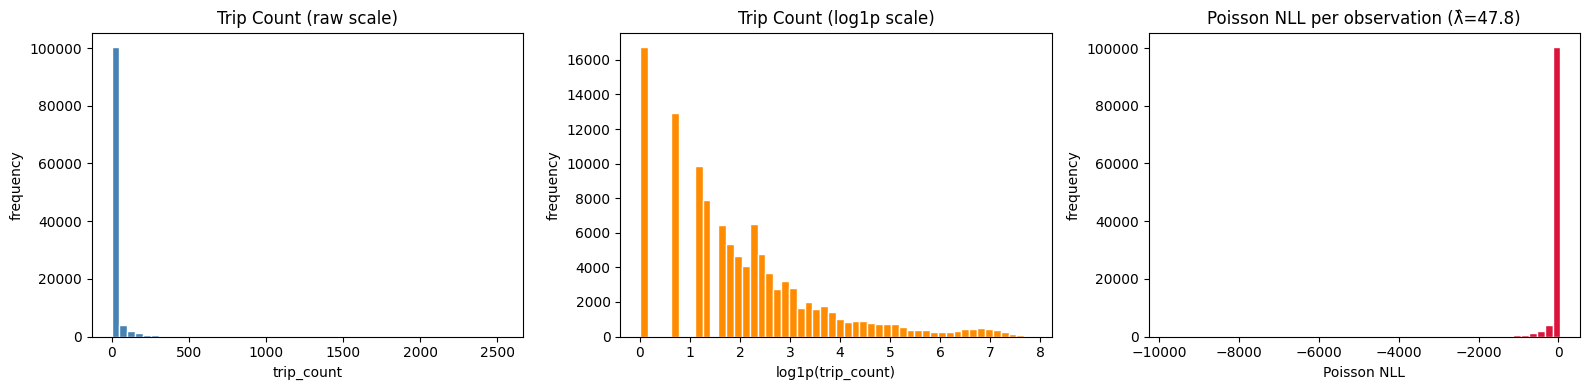

In [67]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Visualization: Trip Count Distribution   #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import matplotlib.pyplot as plt

y_all       = data[TARGET_COL].values.astype(float)
lambda_hat  = y_all.mean()
dispersion  = y_all.var() / lambda_hat          # >1 indicates overdispersion vs. Poisson

# per-observation Poisson NLL at the fitted rate lambda_hat (up to the constant log(y!) term)
poisson_nll = lambda_hat - y_all * np.log(lambda_hat)

print(f"Empirical mean (lambda_hat) : {lambda_hat:.4f}")
print(f"Empirical variance          : {y_all.var():.4f}")
print(f"Dispersion (var / mean)     : {dispersion:.4f}  ({'overdispersed' if dispersion > 1 else 'underdispersed / Poisson-consistent'})")
print(f"Mean Poisson NLL @ lambda_hat: {poisson_nll.mean():.4f}  (up to const. log(y!))")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y_all, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Trip Count (raw scale)")
axes[0].set_xlabel("trip_count")
axes[0].set_ylabel("frequency")

axes[1].hist(np.log1p(y_all), bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("Trip Count (log1p scale)")
axes[1].set_xlabel("log1p(trip_count)")
axes[1].set_ylabel("frequency")

axes[2].hist(poisson_nll, bins=50, color="crimson", edgecolor="white")
axes[2].set_title(f"Poisson NLL per observation (λ̂={lambda_hat:.1f})")
axes[2].set_xlabel("Poisson NLL")
axes[2].set_ylabel("frequency")

plt.tight_layout()
plt.show()

## 3.2.16 Visualization: Architecture Comparison

Side-by-side comparison of the three **tuned** architectures, aggregated over seeds (mean ± std):

- **left** — train / validation / test loss, all under the training criterion (`config.LOSS`), so the three bars per architecture share one scale and gaps indicate over-/underfitting;
- **right** — test-set MAE on the raw trip-count scale (the headline metric).


Training criterion: nb_nll (raw counts), 1 seed(s)

               train_loss         val_loss        test_loss               mae
Baseline  2.5923 ± 0.0000  2.6799 ± 0.0000  2.6549 ± 0.0000  16.3500 ± 0.0000
Deeper    2.5781 ± 0.0000  2.6860 ± 0.0000  2.6675 ± 0.0000  17.4308 ± 0.0000
Wider     2.6481 ± 0.0000  2.7034 ± 0.0000  2.6427 ± 0.0000  17.5580 ± 0.0000


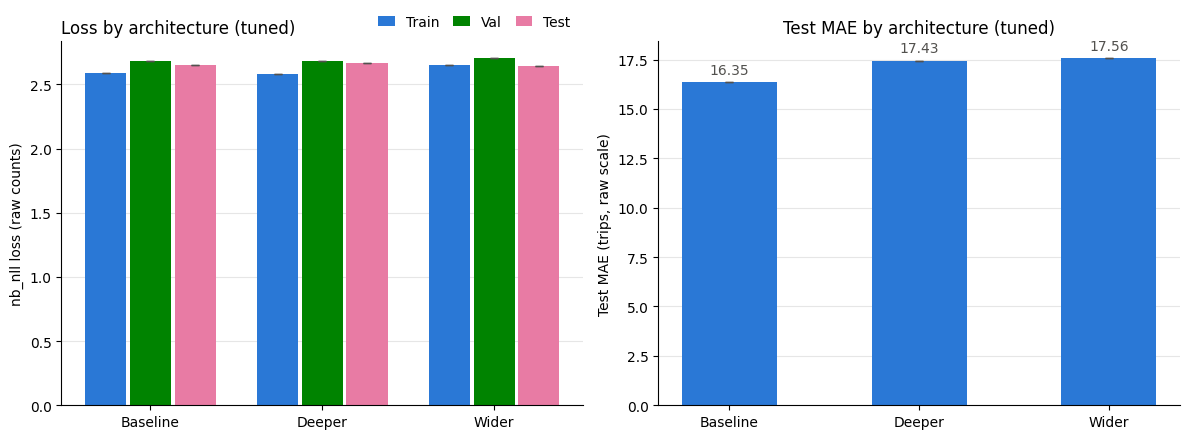

In [68]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Visualization: Architecture Comparison  #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import matplotlib.pyplot as plt

ARCH_RUNS = {
    "Baseline": (tuned_models,        tuned_train_losses,        tuned_val_losses),
    "Deeper":   (tuned_deeper_models, tuned_deeper_train_losses, tuned_deeper_val_losses),
    "Wider":    (tuned_wider_models,  tuned_wider_train_losses,  tuned_wider_val_losses),
}

_X_test_t = torch.as_tensor(X_test, dtype=torch.float32).to(device)
_g_test_t = torch.as_tensor(ca_test, dtype=torch.long).to(device)
_y_target = y_test if IS_POISSON else np.log1p(y_test)   # test target on the training scale

def _test_loss_and_mae(model):
    """Per-seed test loss (training criterion) and raw-scale test MAE."""
    model.eval()
    with torch.no_grad():
        preds_raw = model(_X_test_t, _g_test_t).cpu().numpy().flatten()
    if config.LOSS == "mae":
        test_loss = float(np.mean(np.abs(preds_raw - _y_target)))
    elif config.LOSS == "mse":
        test_loss = float(np.mean((preds_raw - _y_target) ** 2))
    elif config.LOSS == "poisson_nll":
        test_loss = float(np.mean(np.exp(preds_raw) - _y_target * preds_raw))
    else:  # nb_nll — evaluate with the model's trained dispersion
        test_loss = float(nb_nll_loss(torch.as_tensor(preds_raw, dtype=torch.float32),
                                      torch.as_tensor(_y_target, dtype=torch.float32),
                                      model.log_theta.detach().cpu()))
    preds = np.exp(preds_raw) if IS_POISSON else np.expm1(preds_raw)
    return test_loss, float(np.mean(np.abs(preds - y_test)))

stats = {}
for _label, (_models, _tr, _vl) in ARCH_RUNS.items():
    _per_seed = [_test_loss_and_mae(m) for m in _models]
    stats[_label] = {
        "train_loss": (np.mean(_tr), np.std(_tr)),
        "val_loss":   (np.mean(_vl), np.std(_vl)),
        "test_loss":  (np.mean([t for t, _ in _per_seed]), np.std([t for t, _ in _per_seed])),
        "mae":        (np.mean([m for _, m in _per_seed]), np.std([m for _, m in _per_seed])),
    }

summary_df = pd.DataFrame(
    {a: {k: f"{m:.4f} ± {s:.4f}" for k, (m, s) in d.items()} for a, d in stats.items()}
).T
print(f"Training criterion: {config.LOSS} ({'raw counts' if IS_POISSON else 'log1p scale'}), "
      f"{len(SEEDS)} seed(s)\n")
print(summary_df.to_string())

_archs  = list(stats)
_splits = [("train_loss", "Train", "#2a78d6"),
           ("val_loss",   "Val",   "#008300"),
           ("test_loss",  "Test",  "#e87ba4")]

fig, (ax_loss, ax_mae) = plt.subplots(1, 2, figsize=(12, 4.5))
_x = np.arange(len(_archs))

for _i, (_split, _sl, _c) in enumerate(_splits):
    _means = [stats[a][_split][0] for a in _archs]
    _stds  = [stats[a][_split][1] for a in _archs]
    ax_loss.bar(_x + (_i - 1) * 0.26, _means, width=0.24, color=_c, label=_sl,
                yerr=_stds, capsize=3, error_kw=dict(ecolor="#52514e", lw=1))
ax_loss.set_xticks(_x, _archs)
ax_loss.set_ylabel(f"{config.LOSS} loss ({'raw counts' if IS_POISSON else 'log1p scale'})")
ax_loss.set_title("Loss by architecture (tuned)", loc="left")
ax_loss.legend(frameon=False, loc="lower right", bbox_to_anchor=(1, 1.0),
               ncols=3, handlelength=1.2, columnspacing=1.0)

_means = [stats[a]["mae"][0] for a in _archs]
_stds  = [stats[a]["mae"][1] for a in _archs]
ax_mae.bar(_x, _means, width=0.5, color="#2a78d6",
           yerr=_stds, capsize=3, error_kw=dict(ecolor="#52514e", lw=1))
for _xi, _m, _s in zip(_x, _means, _stds):
    ax_mae.annotate(f"{_m:.2f}", (_xi, _m + _s), ha="center", va="bottom",
                    xytext=(0, 4), textcoords="offset points", color="#52514e")
ax_mae.set_xticks(_x, _archs)
ax_mae.set_ylabel("Test MAE (trips, raw scale)")
ax_mae.set_title("Test MAE by architecture (tuned)")

for _ax in (ax_loss, ax_mae):
    _ax.grid(axis="y", color="0.90", linewidth=0.8)
    _ax.set_axisbelow(True)
    for _side in ("top", "right"):
        _ax.spines[_side].set_visible(False)

plt.tight_layout()
plt.show()


### Learning Curves

Per-epoch train / validation / test loss for each tuned architecture, all under the training criterion. The dot marks the best-validation epoch whose weights early stopping restores. Requires re-running the tuned training cells once, since `train_model` now records the history on the returned models.


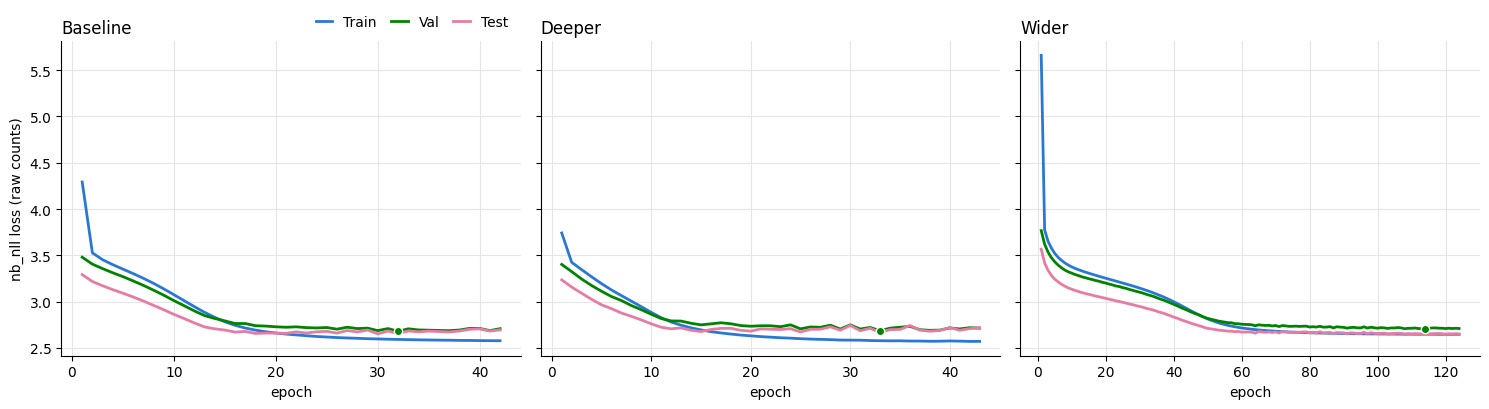

In [69]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Visualization: Learning Curves          #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

import matplotlib.pyplot as plt

ARCH_CURVES = {
    "Baseline": tuned_models,
    "Deeper":   tuned_deeper_models,
    "Wider":    tuned_wider_models,
}
_colors = {"train": "#2a78d6", "val": "#008300", "test": "#e87ba4"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for _ax, (_label, _models) in zip(axes, ARCH_CURVES.items()):
    for _si, _model in enumerate(_models):
        _h = getattr(_model, "history", None)
        if _h is None:
            raise RuntimeError("model has no training history — re-run the tuned "
                               "training cells (train_model records it now)")
        _epochs = np.arange(1, len(_h["train"]) + 1)
        for _split in ("train", "val", "test"):
            if _h[_split]:
                _ax.plot(_epochs, _h[_split], color=_colors[_split], lw=2,
                         alpha=1.0 if _si == 0 else 0.4,
                         label=_split.capitalize() if _si == 0 else None)
        _best = int(np.argmin(_h["val"]))   # epoch restored by early stopping
        _ax.plot(_best + 1, _h["val"][_best], "o", ms=6, color=_colors["val"],
                 markeredgecolor="white", zorder=3)
    _ax.set_title(_label, loc="left")
    _ax.set_xlabel("epoch")
    _ax.grid(color="0.90", linewidth=0.8)
    _ax.set_axisbelow(True)
    for _side in ("top", "right"):
        _ax.spines[_side].set_visible(False)

axes[0].set_ylabel(f"{config.LOSS} loss ({'raw counts' if IS_POISSON else 'log1p scale'})")
axes[0].legend(frameon=False, loc="lower right", bbox_to_anchor=(1, 1.0),
               ncols=3, handlelength=1.2, columnspacing=1.0)

plt.tight_layout()
plt.show()


### Statistical Significance — Wilcoxon Signed-Rank

Non-parametric paired test of whether each **tuned** network is more accurate than the benchmark models on the held-out test set, using per-row absolute errors (the tuned architectures are seed-ensembled — mean predicted count). Every model scores the same test rows, so the errors are paired. Reported with a Holm-corrected one-sided *p*-value (H1: NN error < benchmark error) and practical effect sizes, since on a test set this large even trivial gaps come out "significant".

This test aims to **identify whether a model adds value, not whether neural networks should be deployed**. If the difference in performance is not statistically significant, the model adds no measurable value over the benchmark. If it is significant, further analysis is needed to determine whether that value justifies the cost.

In [70]:
# # # # # # # # # # # # # # # # # # # # # #
#                                         #
# Statistical Significance (Wilcoxon)     #
#                                         #
# # # # # # # # # # # # # # # # # # # # # #

from scipy.stats import wilcoxon

_X_test_t = torch.as_tensor(X_test, dtype=torch.float32).to(device)
_g_test_t = torch.as_tensor(ca_test, dtype=torch.long).to(device)
_y        = np.asarray(y_test, dtype=float)


def _nn_ensemble_preds(models):
    """Seed-ensembled predicted counts (raw trip-count scale) on the test set."""
    acc = np.zeros(len(_y), dtype=float)
    for _m in models:
        _m.eval()
        with torch.no_grad():
            _pr = _m(_X_test_t, _g_test_t).cpu().numpy().flatten()
        acc += np.exp(_pr) if IS_POISSON else np.expm1(_pr)
    return acc / len(models)


nn_preds = {
    "Baseline (tuned)": _nn_ensemble_preds(tuned_models),
    "Deeper (tuned)":   _nn_ensemble_preds(tuned_deeper_models),
    "Wider (tuned)":    _nn_ensemble_preds(tuned_wider_models),
}
benchmark_preds = {
    "Historical mean": np.asarray(hist_mean_preds, dtype=float),
    "Ridge":           np.asarray(ridge_preds,     dtype=float),
}

_rows = []
for _mname, _mpred in nn_preds.items():
    _ae_nn = np.abs(_mpred - _y)
    for _bname, _bpred in benchmark_preds.items():
        _ae_bm = np.abs(_bpred - _y)
        _diff  = _ae_nn - _ae_bm
        _stat, _p = wilcoxon(_ae_nn, _ae_bm, alternative="less", zero_method="wilcox")
        _rows.append({
            "NN model"            : _mname,
            "Benchmark"           : _bname,
            "median AE (NN)"      : float(np.median(_ae_nn)),
            "median AE (bench)"   : float(np.median(_ae_bm)),
            "median AE reduction" : float(np.median(_ae_bm) - np.median(_ae_nn)),
            "NN wins %"           : float(100.0 * np.mean(_ae_nn < _ae_bm)),
            "W"                   : float(_stat),
            "p (one-sided)"       : float(_p),
            "n (non-tied)"        : int(np.sum(_diff != 0)),
        })

sig_df = pd.DataFrame(_rows)

# Holm-Bonferroni step-down correction across all comparisons
_pv  = sig_df["p (one-sided)"].to_numpy()
_ord = np.argsort(_pv)
_adj = np.empty_like(_pv)
_run = 0.0
for _rank, _idx in enumerate(_ord):
    _run = max(_run, (len(_pv) - _rank) * _pv[_idx])
    _adj[_idx] = min(_run, 1.0)
sig_df["p (Holm)"]    = _adj
sig_df["significant"] = sig_df["p (Holm)"] < 0.05

print("Wilcoxon signed-rank - tuned NN (seed-ensemble) vs benchmarks")
print(f"paired over {len(_y):,} test rows | H1: NN abs-error < benchmark abs-error | alpha = 0.05\n")
with pd.option_context("display.width", 200, "display.max_columns", None,
                       "display.float_format", lambda v: f"{v:.4g}"):
    print(sig_df.to_string(index=False))


Wilcoxon signed-rank - tuned NN (seed-ensemble) vs benchmarks
paired over 16,863 test rows | H1: NN abs-error < benchmark abs-error | alpha = 0.05

        NN model       Benchmark  median AE (NN)  median AE (bench)  median AE reduction  NN wins %         W  p (one-sided)  n (non-tied)   p (Holm)  significant
Baseline (tuned) Historical mean           1.812              2.188               0.3763      55.51 5.746e+07      1.56e-103         16863 3.119e-103         True
Baseline (tuned)           Ridge           1.812              9.965                8.153      73.33 2.234e+07              0         16863          0         True
  Deeper (tuned) Historical mean            1.76              2.188               0.4283      55.11 5.878e+07      7.743e-85         16863  7.743e-85         True
  Deeper (tuned)           Ridge            1.76              9.965                8.205      73.57 2.286e+07              0         16863          0         True
   Wider (tuned) Historical mean     